In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *
from plot_functions import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import hictkpy as htk
from matplotlib.colors import LogNorm

from pathlib import Path

from Bead_sequence_MC.mf_chromatin_functions import *

Using cupy


In [2]:
free_energy_grid = np.load("../results_parameter_sweep_phi01/free_energy_grid.npy", allow_pickle=True)
print(free_energy_grid.shape)
print(np.array((free_energy_grid[-1, -1])).shape)

(9, 7)
(370, 3)


In [3]:
#ChiNpp = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])
#ChiNps = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])

ChiNpp = np.array([200, 250, 300, 325, 350, 400, 450, 500, 550])
ChiNps = np.array([200, 250, 300, 325, 350, 400, 450])
its = 7900

In [4]:
M, K = free_energy_grid.shape
final_energy_grid = np.zeros((len(ChiNpp), len(ChiNps), 3))
for i in range(M):
    for j in range(K):
        free_energy_hist = np.array(free_energy_grid[i,j])
        if (np.max(abs(free_energy_hist)) < 160) & (free_energy_hist.shape[0] > its):
            final_energy_grid[i,j,:] = free_energy_hist[-1,:]

final_energy_grid = np.where(final_energy_grid == 0, np.nan, final_energy_grid)

In [11]:
print(final_energy_grid.shape)
print(final_energy_grid[4,:,0].shape)

(9, 7, 3)
(7,)


ChiNpp =  350


<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
C:\Users\19162\AppData\Local\Temp\ipykernel_36236\2444390287.py:11: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("$\chi_{PS} N$")


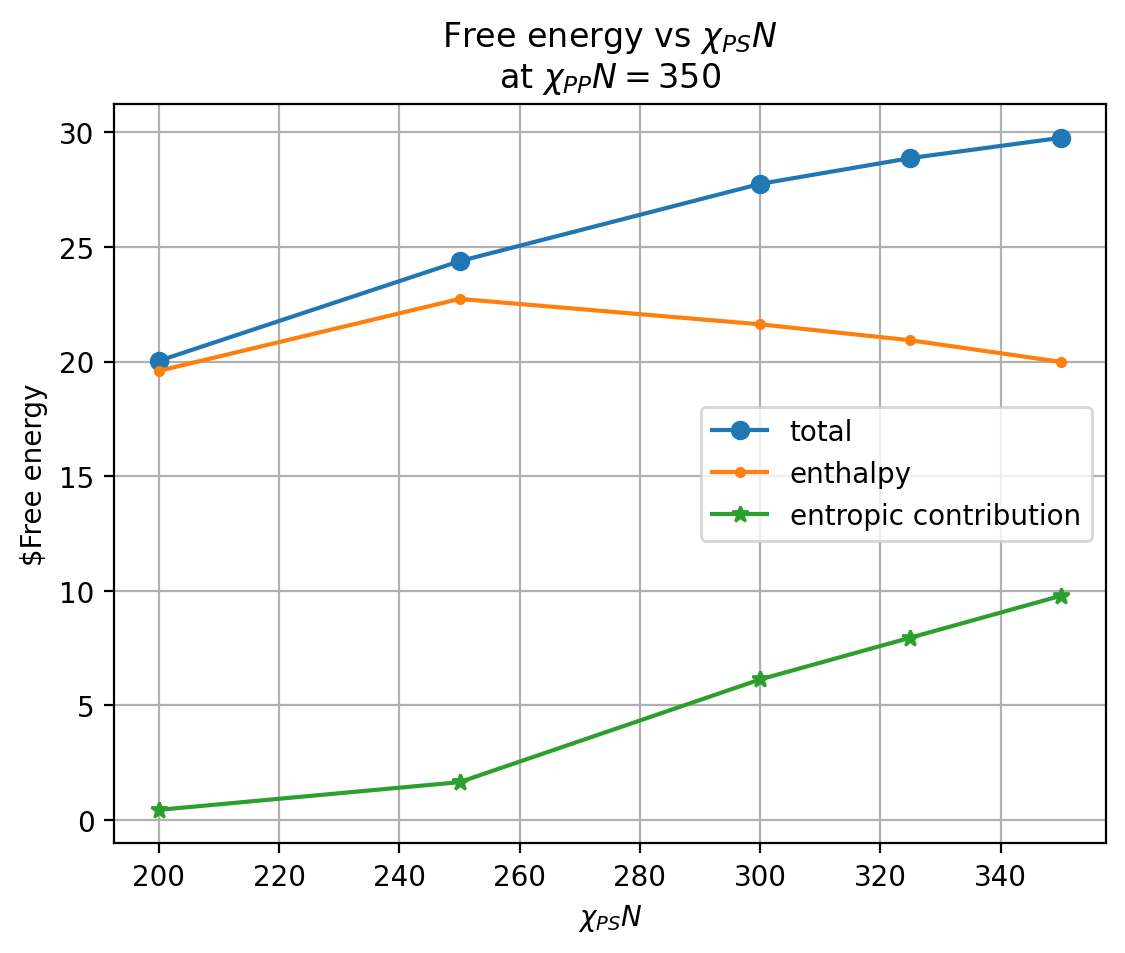

In [33]:
idx_pp = 4
print("ChiNpp = ", ChiNpp[idx_pp])
plt.figure(dpi = 200)
plt.plot(ChiNps, final_energy_grid[idx_pp, :, 0], label="total", marker='o')
plt.plot(ChiNps, final_energy_grid[idx_pp, :, 1], label="enthalpy", marker='.')
plt.plot(ChiNps, final_energy_grid[idx_pp, :, 2], label="entropic contribution", marker='*')

plt.legend()
plt.title(r"""Free energy vs $\chi_{PS} N$
at $\chi_{PP} N = 350$""")
plt.xlabel("$\chi_{PS} N$")
plt.ylabel("$Free energy")
plt.grid()

ChiNps =  350


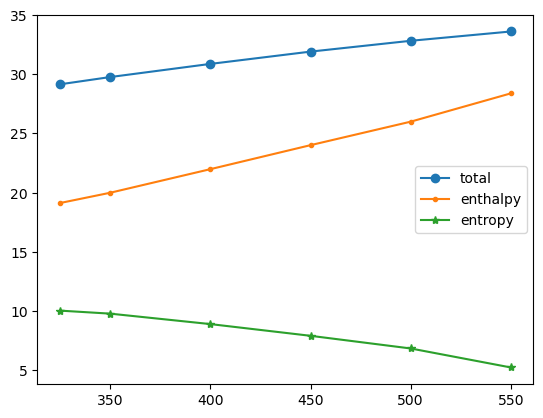

In [28]:
idx_ps = 4
print("ChiNps = ", ChiNps[idx_ps])

plt.plot(ChiNpp, final_energy_grid[:, idx_ps, 0], label="total", marker='o')
plt.plot(ChiNpp, final_energy_grid[:, idx_ps, 1], label="enthalpy", marker='.')
plt.plot(ChiNpp, final_energy_grid[:, idx_ps, 2], label="entropy", marker='*')

plt.legend()

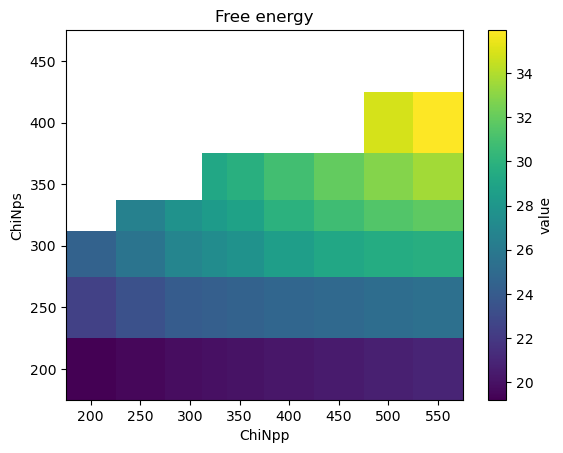

In [22]:
ax = plot_heatmap(final_energy_grid[:,:,0], ChiNpp, ChiNps, title="Free energy")
plt.show()


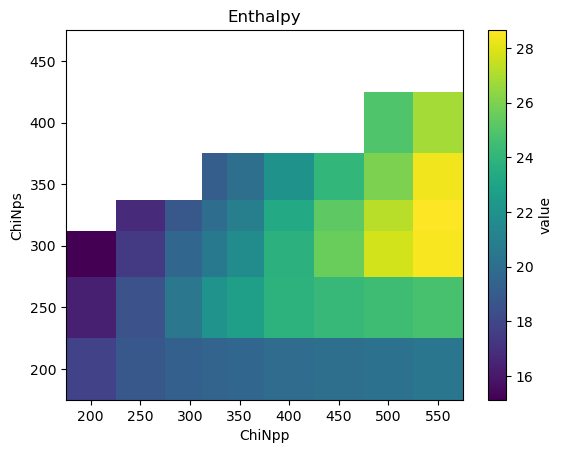

In [23]:
ax = plot_heatmap(final_energy_grid[:,:,1], ChiNpp, ChiNps, title="Enthalpy")
plt.show()

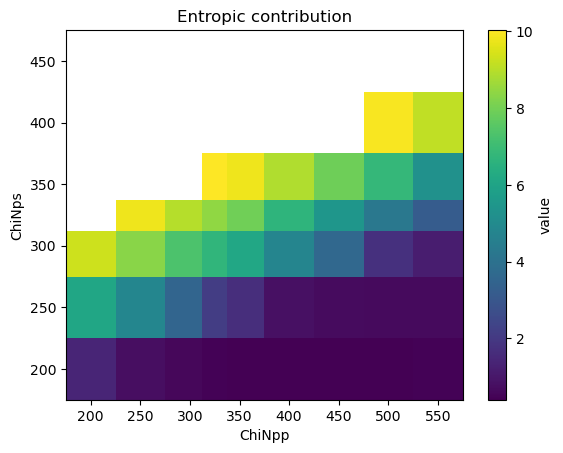

In [24]:
ax = plot_heatmap(final_energy_grid[:,:,2], ChiNpp, ChiNps, title="Entropic contribution")
plt.show()

PP = 200,  PS = 200


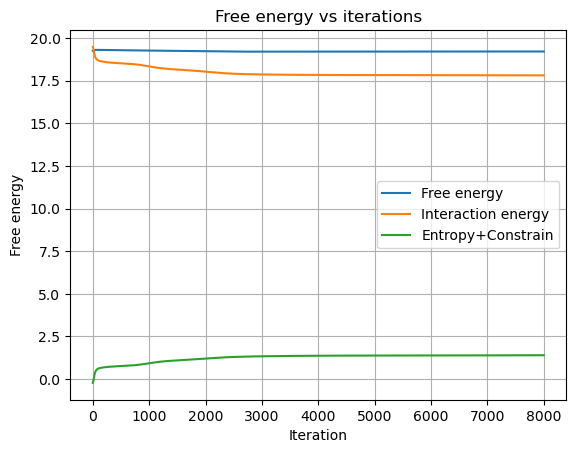

PP = 200,  PS = 250


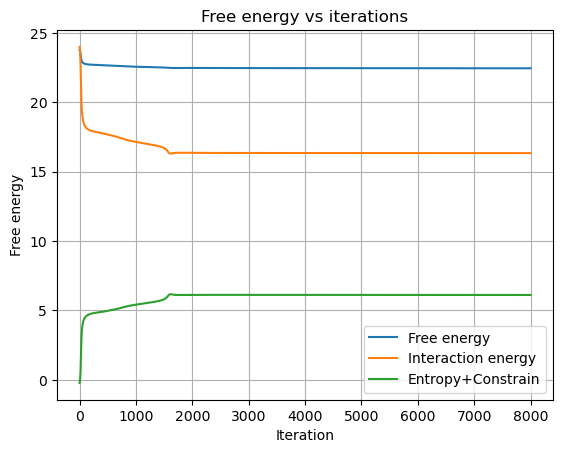

PP = 200,  PS = 300


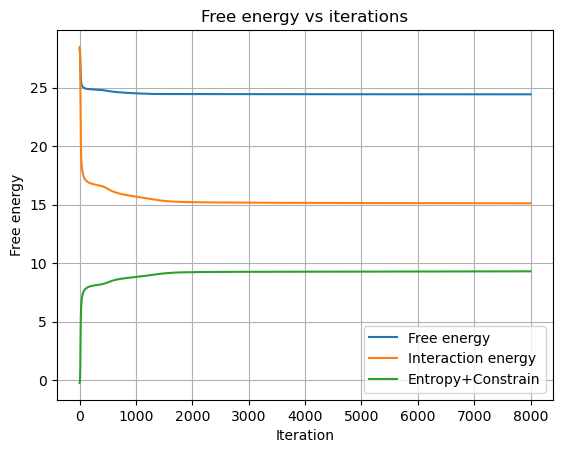

PP = 200,  PS = 325
fail


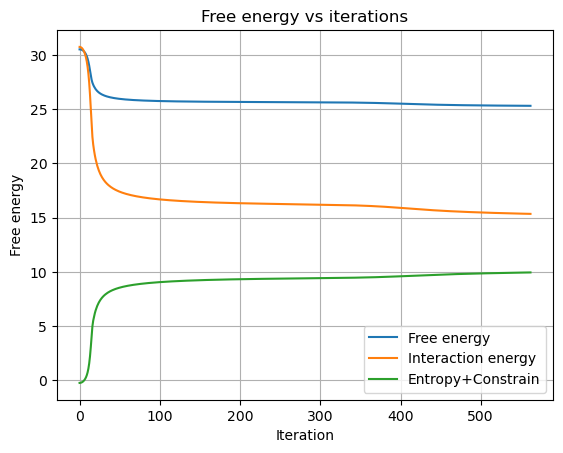

PP = 200,  PS = 350
fail


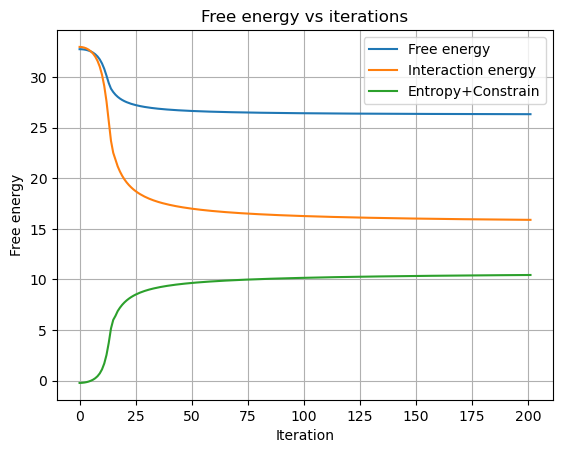

PP = 200,  PS = 400
fail


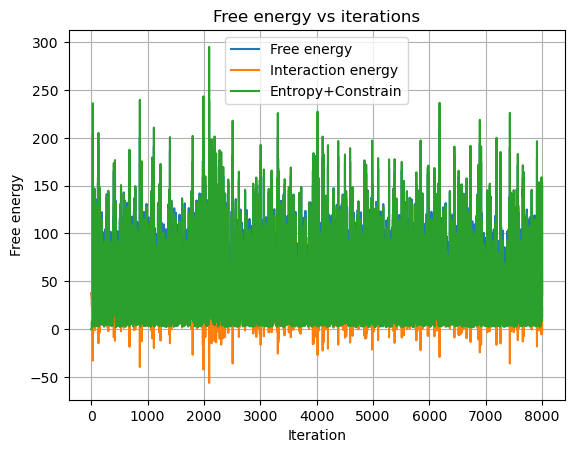

PP = 200,  PS = 450
fail


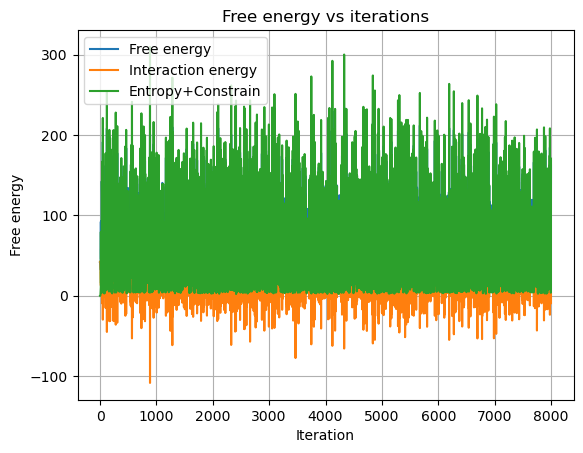

PP = 250,  PS = 200


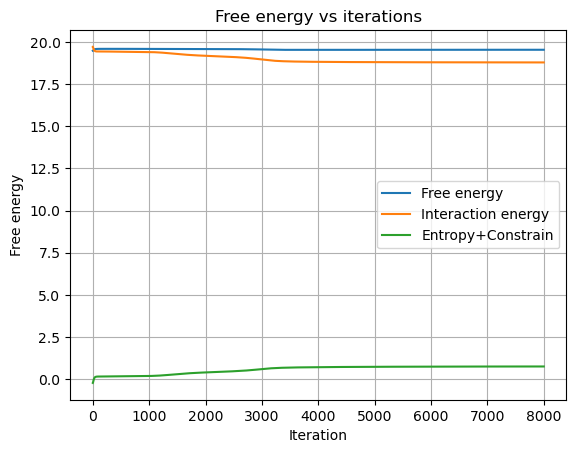

PP = 250,  PS = 250


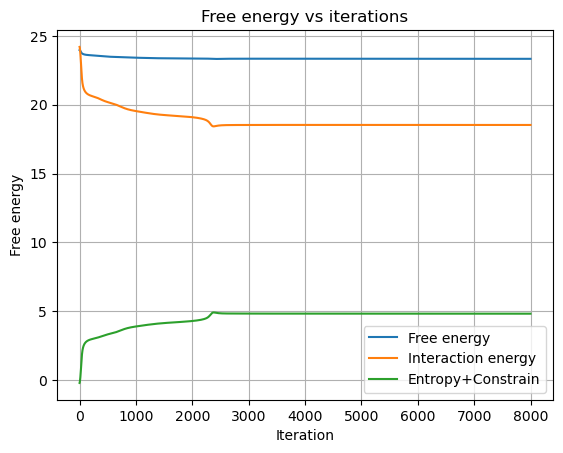

PP = 250,  PS = 300


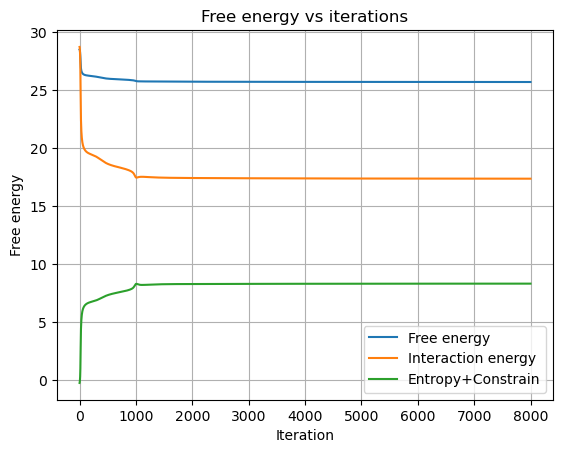

PP = 250,  PS = 325


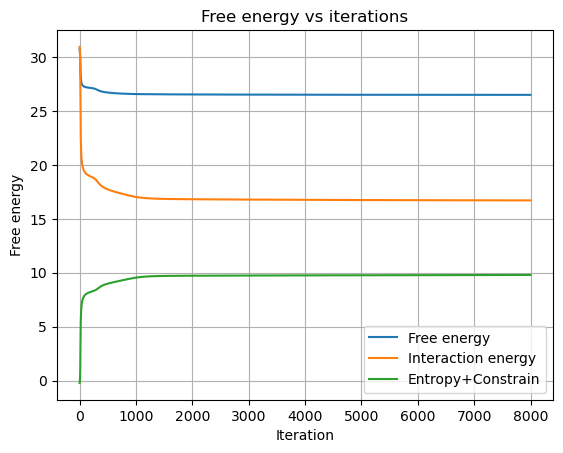

PP = 250,  PS = 350
fail


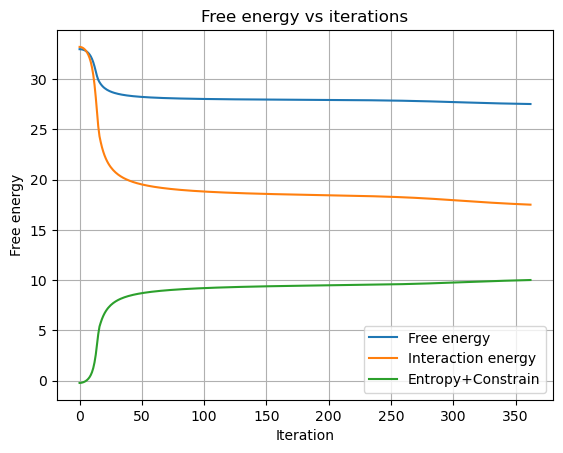

PP = 250,  PS = 400
fail


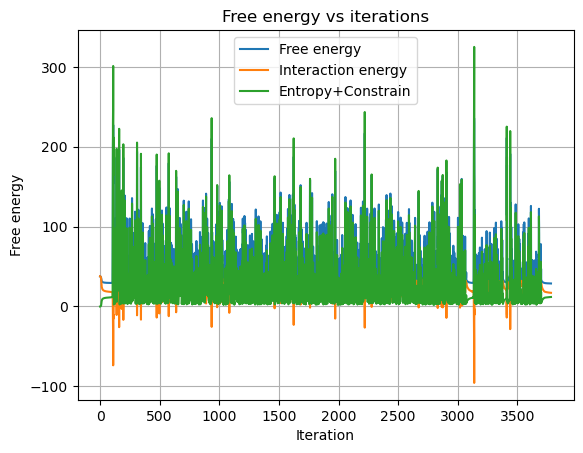

PP = 250,  PS = 450
fail


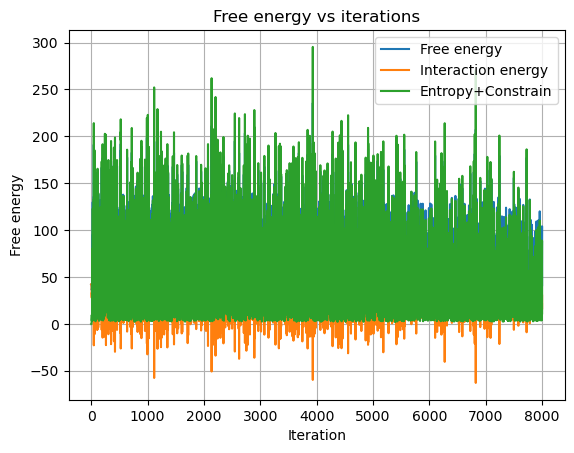

PP = 300,  PS = 200


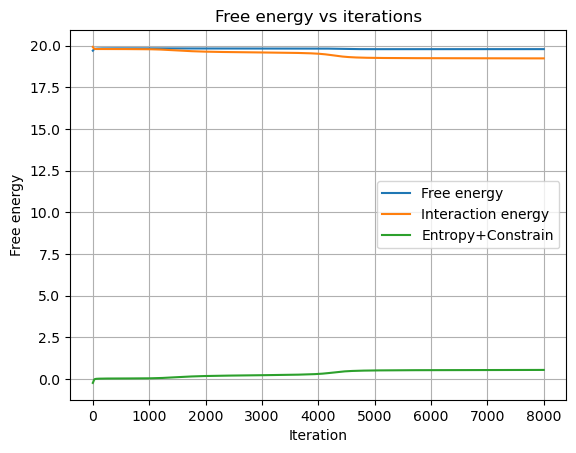

PP = 300,  PS = 250


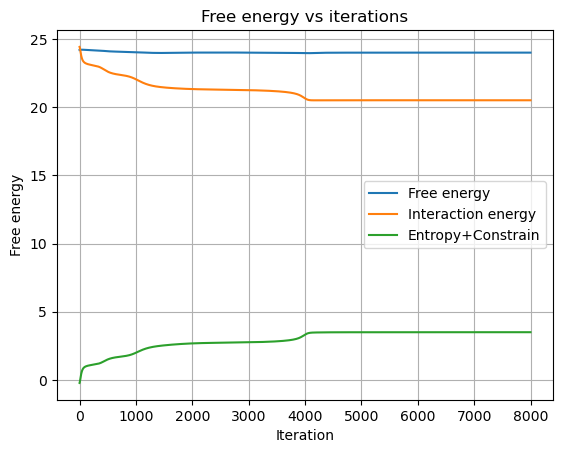

PP = 300,  PS = 300


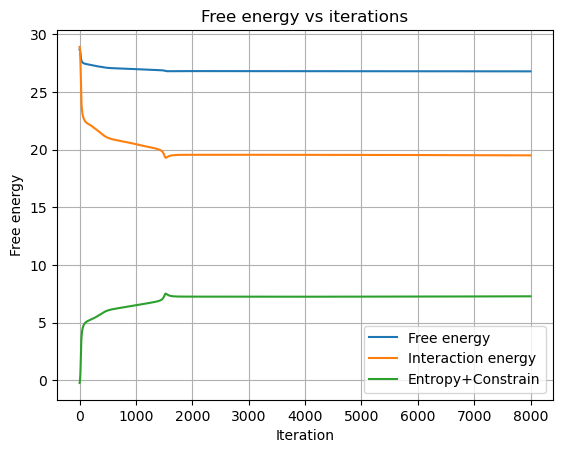

PP = 300,  PS = 325


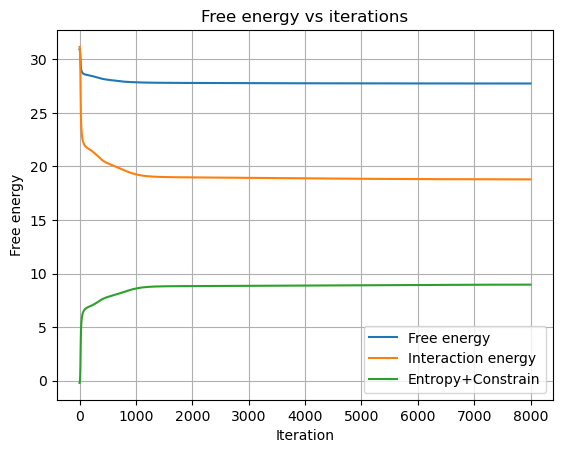

PP = 300,  PS = 350
fail


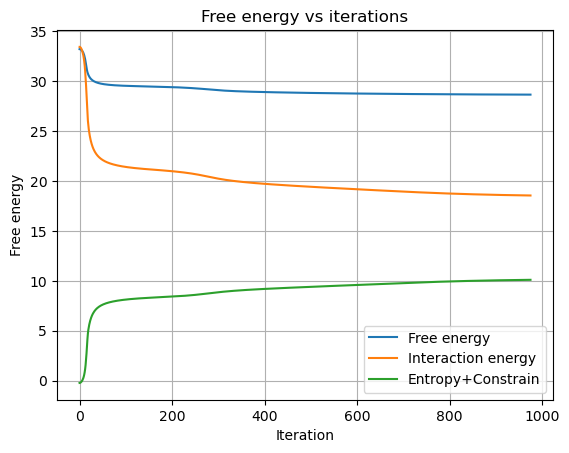

PP = 300,  PS = 400
fail


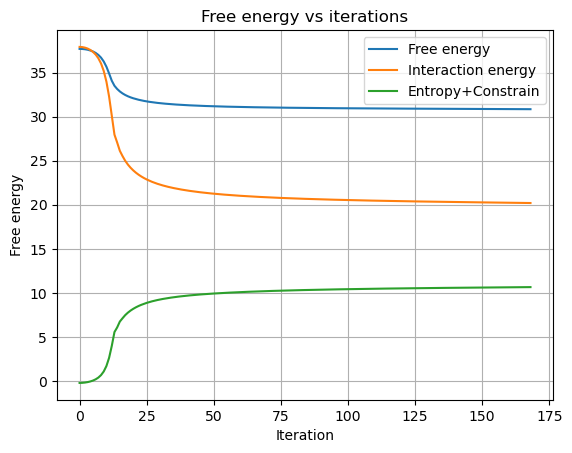

PP = 300,  PS = 450
fail


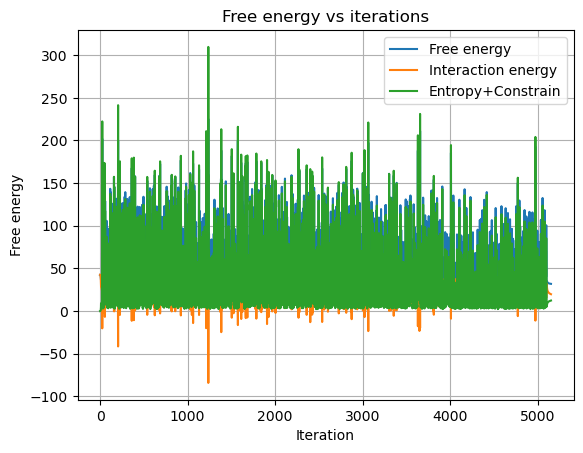

PP = 325,  PS = 200


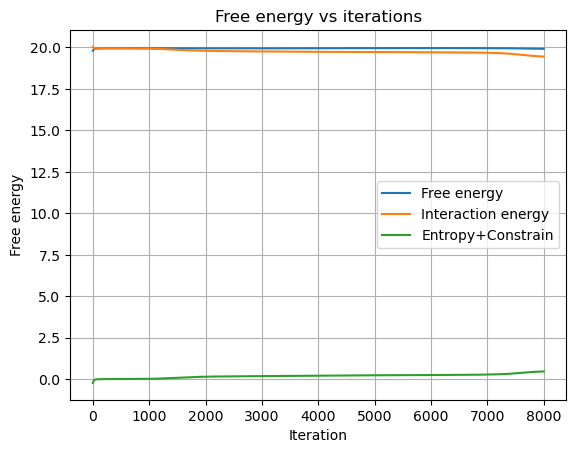

PP = 325,  PS = 250


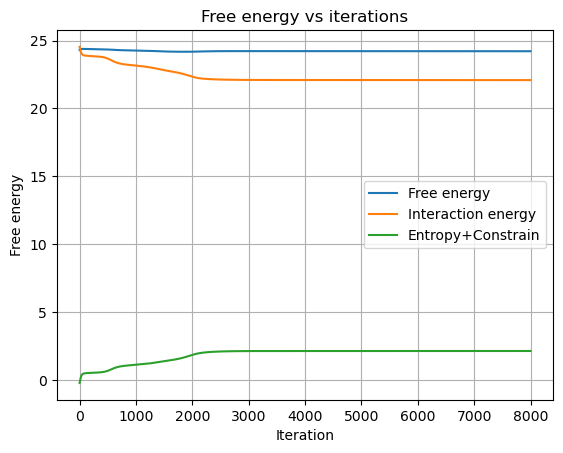

PP = 325,  PS = 300


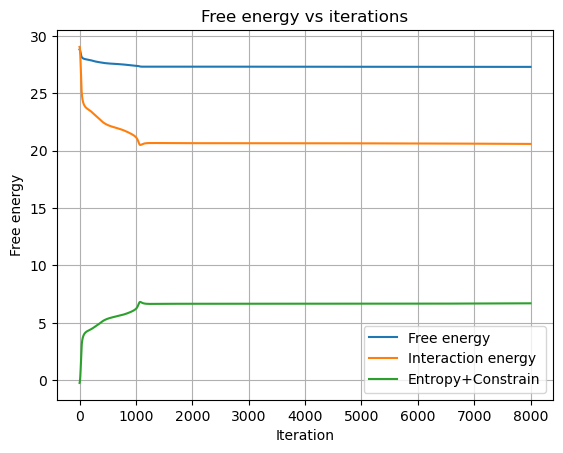

PP = 325,  PS = 325


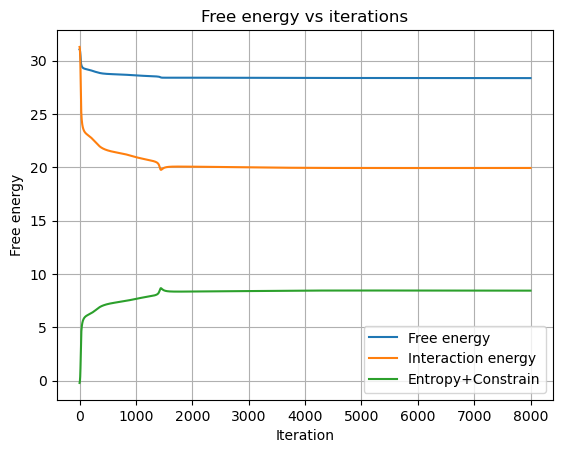

PP = 325,  PS = 350


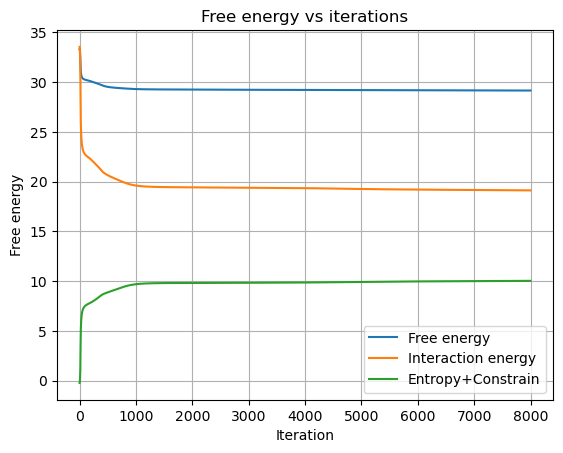

PP = 325,  PS = 400
fail


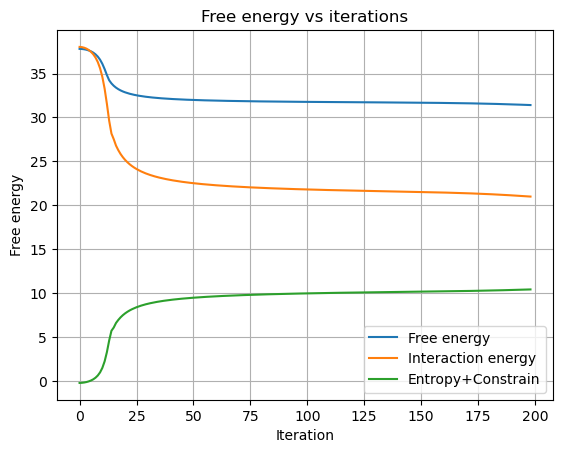

PP = 325,  PS = 450
fail


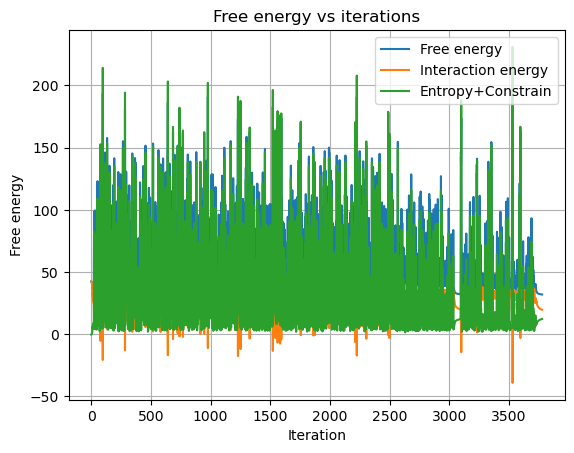

PP = 350,  PS = 200


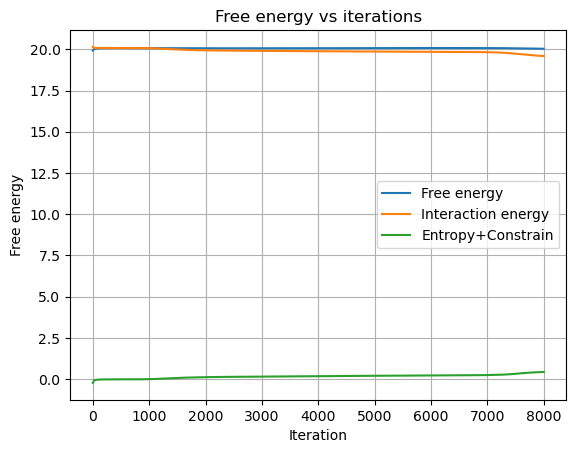

PP = 350,  PS = 250


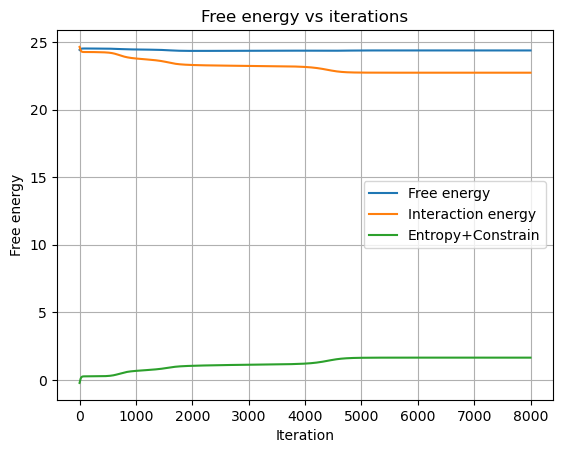

PP = 350,  PS = 300


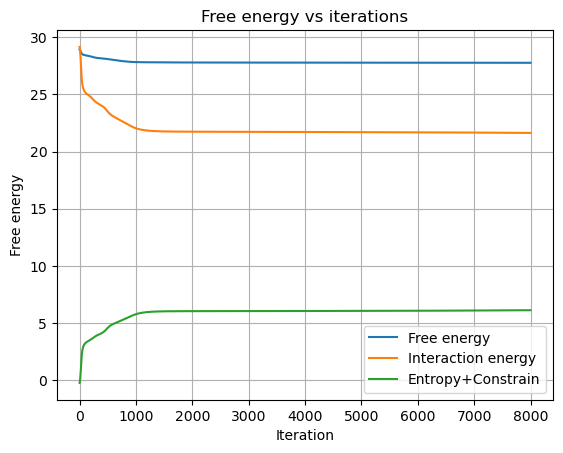

PP = 350,  PS = 325


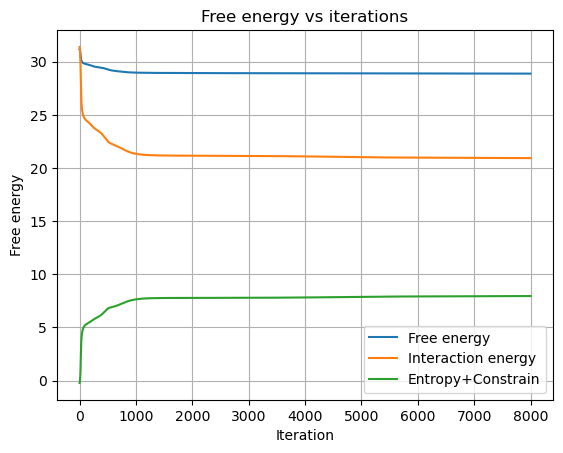

PP = 350,  PS = 350


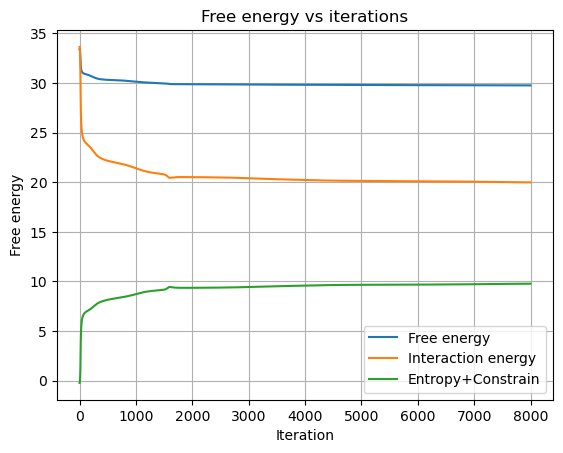

PP = 350,  PS = 400
fail


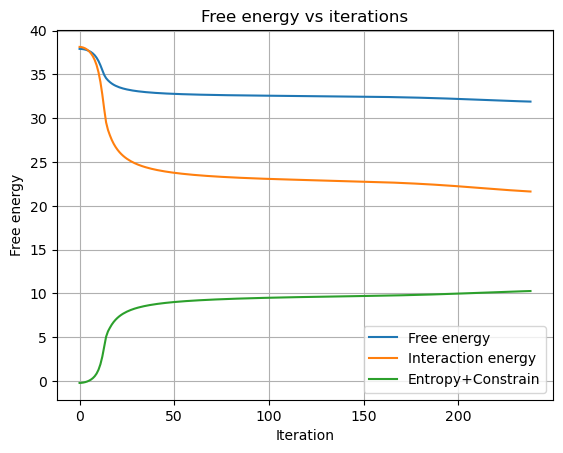

PP = 350,  PS = 450
fail


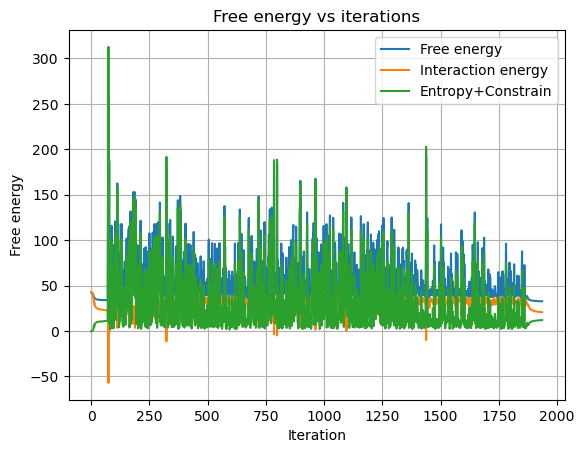

PP = 400,  PS = 200


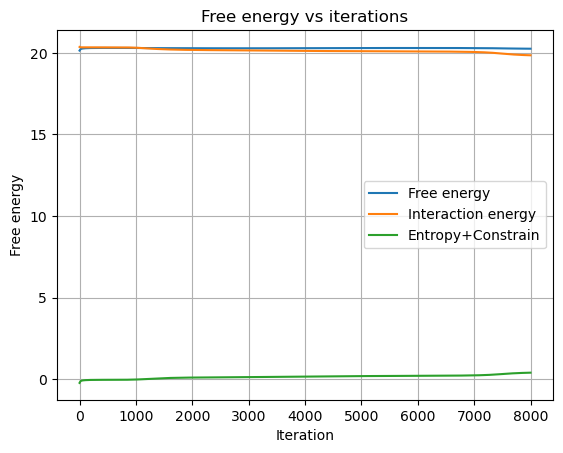

PP = 400,  PS = 250


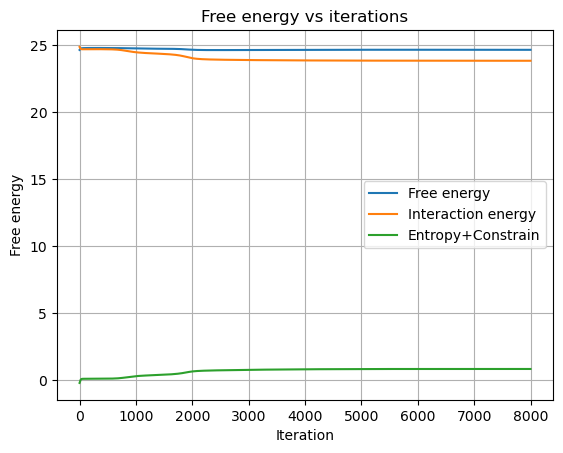

PP = 400,  PS = 300


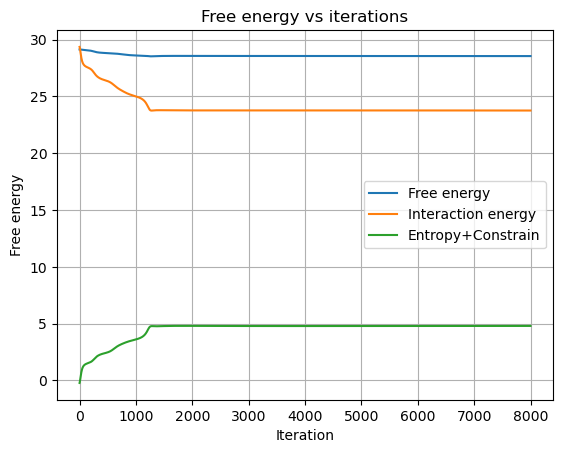

PP = 400,  PS = 325


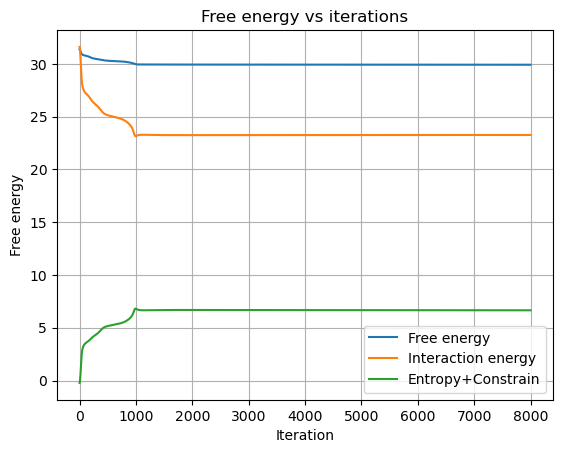

PP = 400,  PS = 350


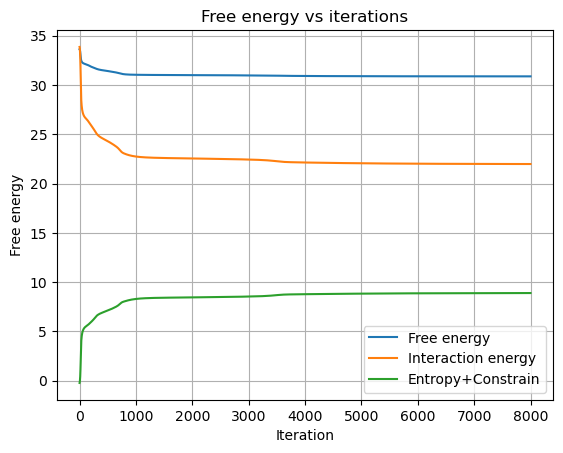

PP = 400,  PS = 400
fail


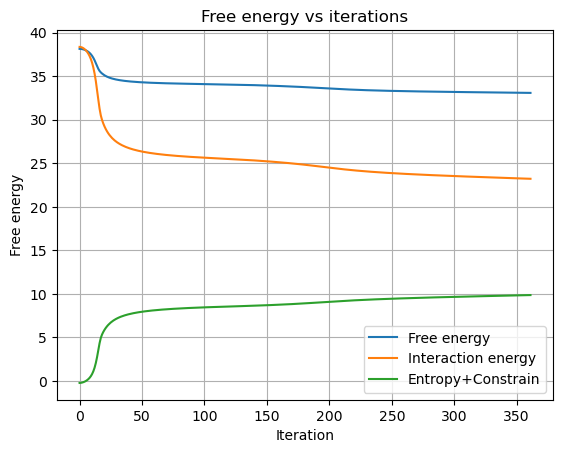

PP = 400,  PS = 450
fail


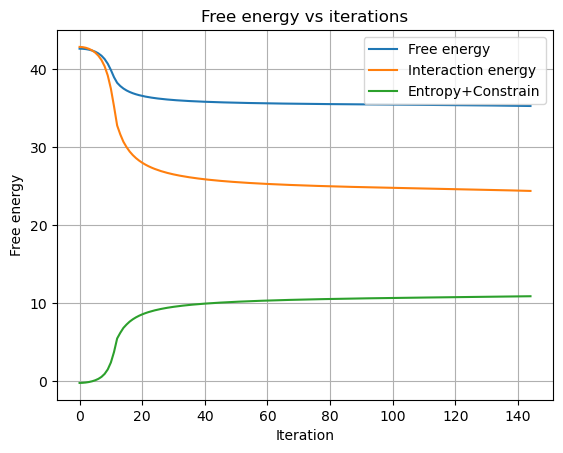

PP = 450,  PS = 200


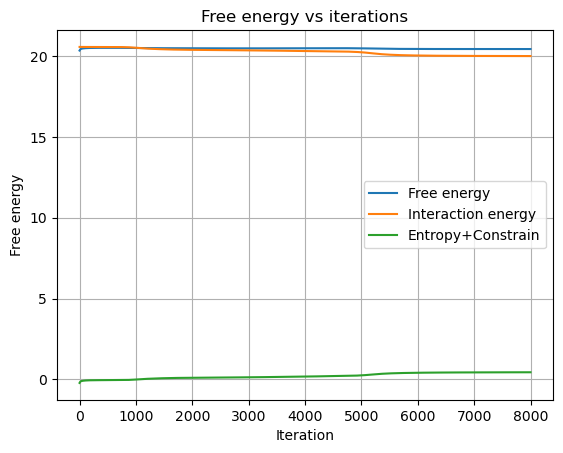

PP = 450,  PS = 250


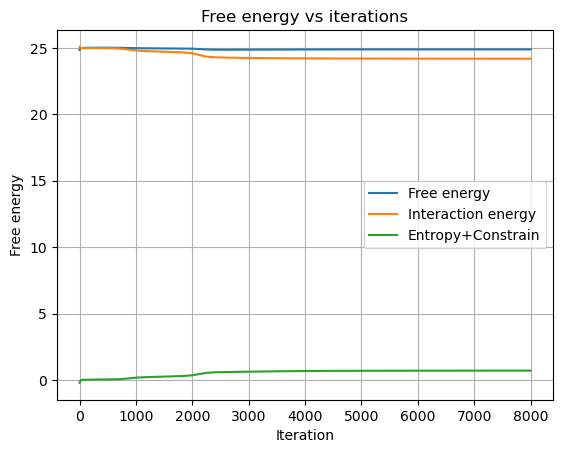

PP = 450,  PS = 300


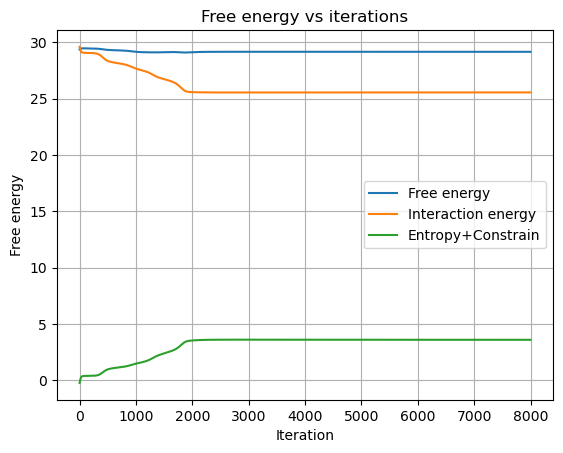

PP = 450,  PS = 325


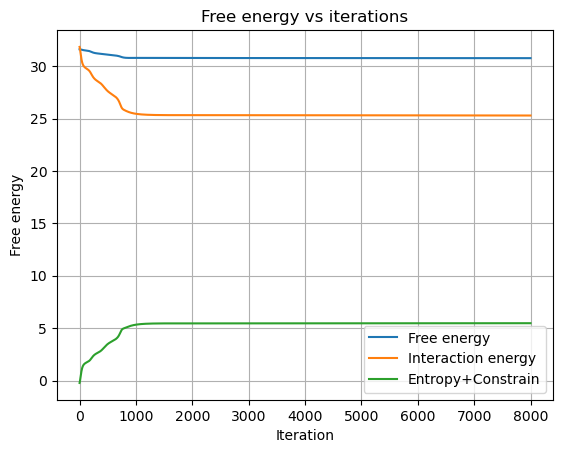

PP = 450,  PS = 350


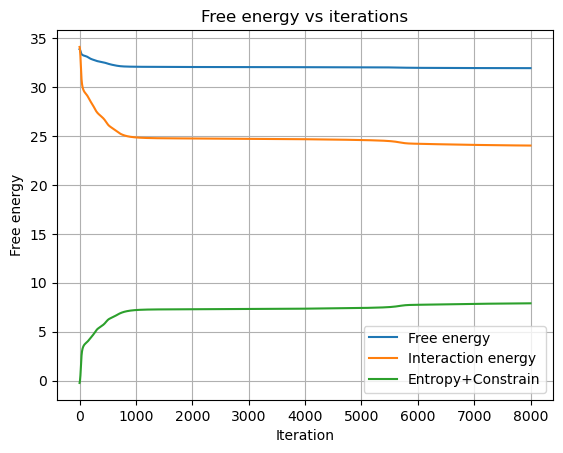

PP = 450,  PS = 400
fail


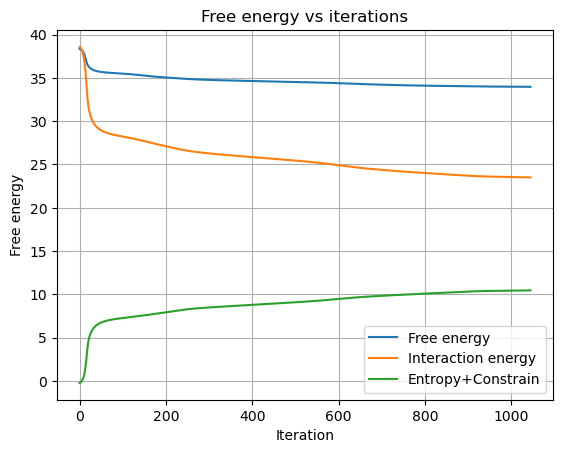

PP = 450,  PS = 450
fail


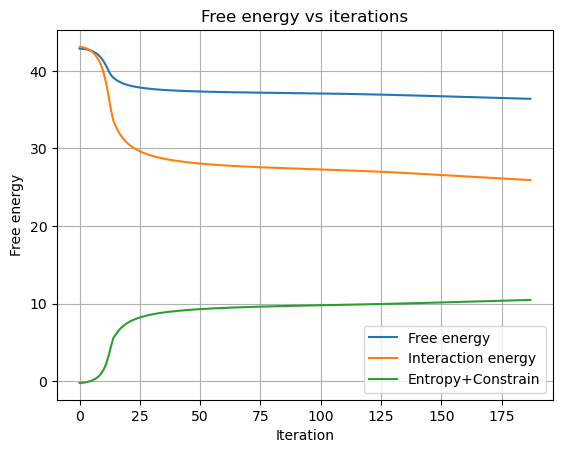

PP = 500,  PS = 200


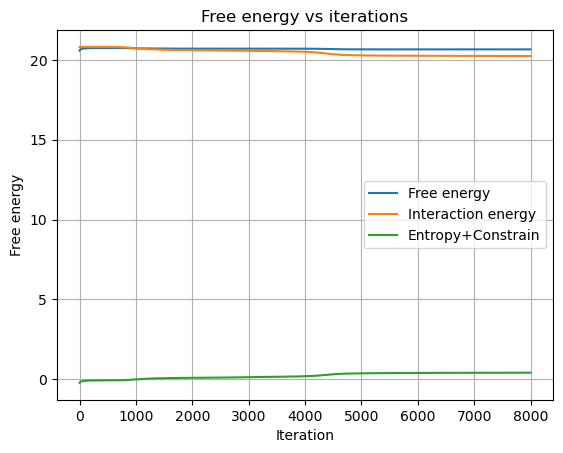

PP = 500,  PS = 250


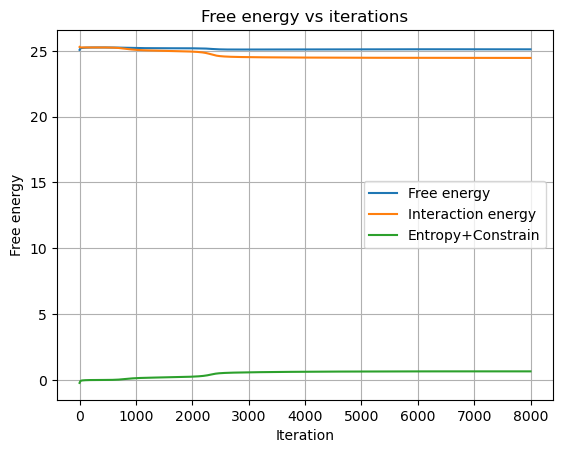

PP = 500,  PS = 300


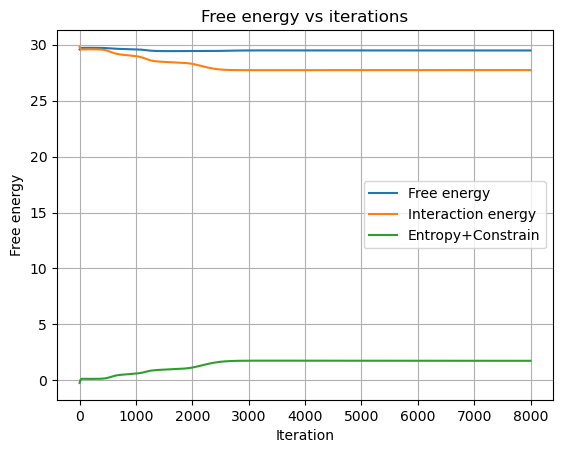

PP = 500,  PS = 325


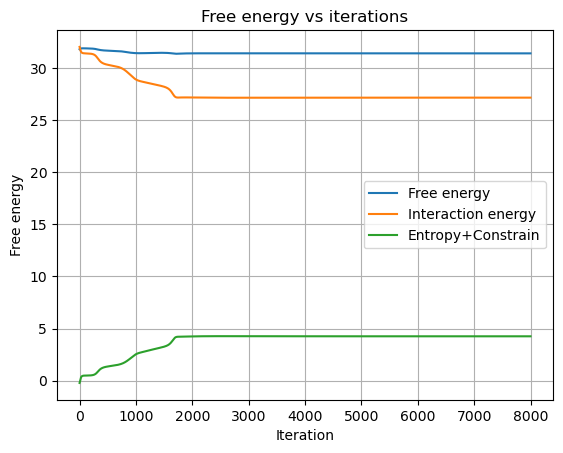

PP = 500,  PS = 350


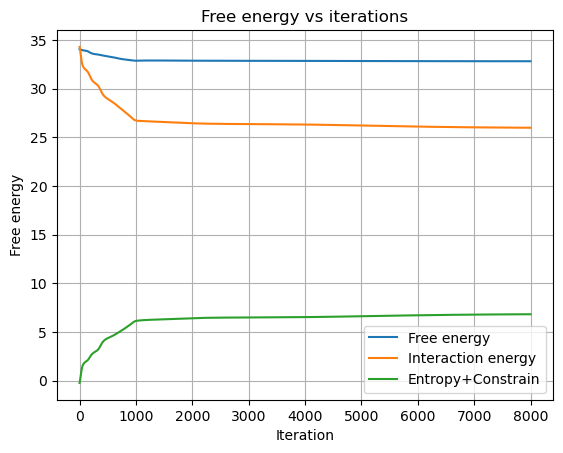

PP = 500,  PS = 400


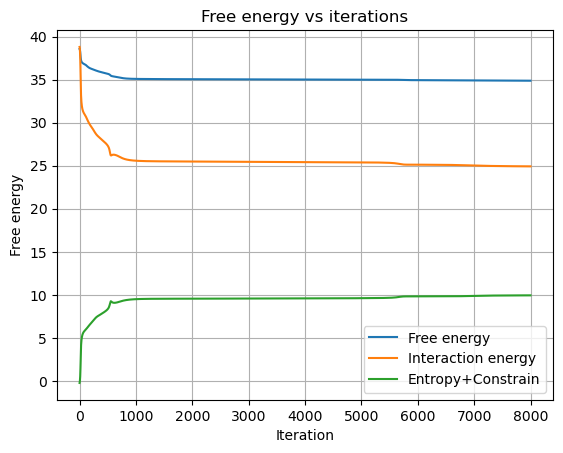

PP = 500,  PS = 450
fail


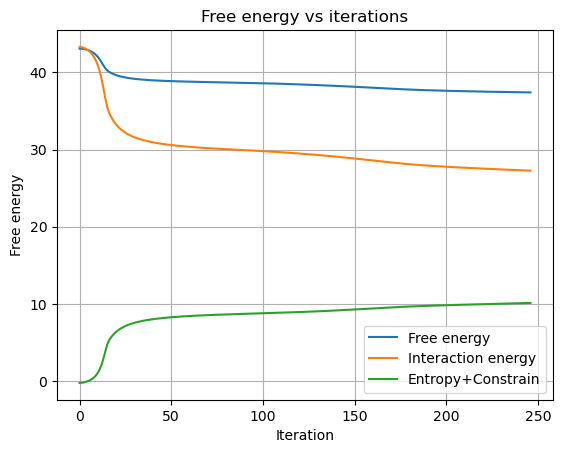

PP = 550,  PS = 200


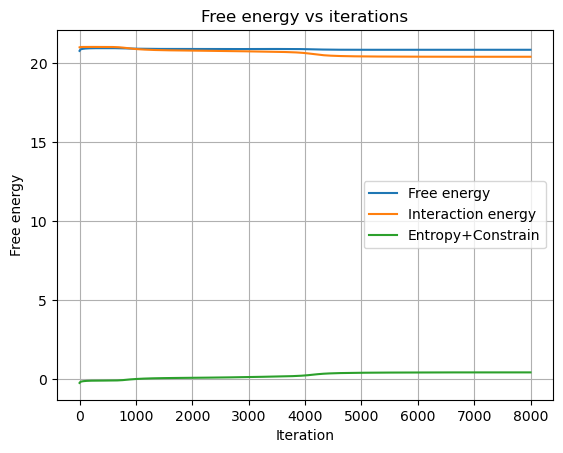

PP = 550,  PS = 250


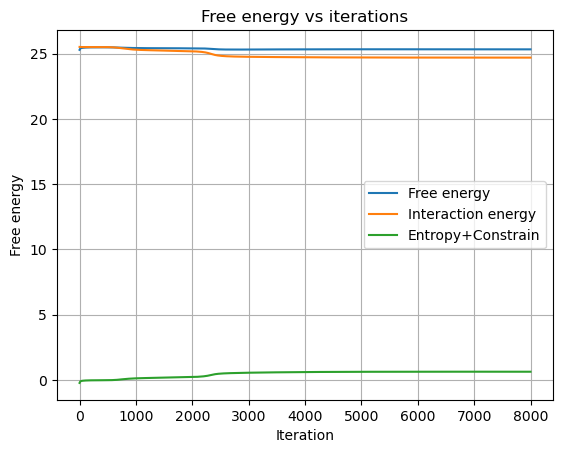

PP = 550,  PS = 300


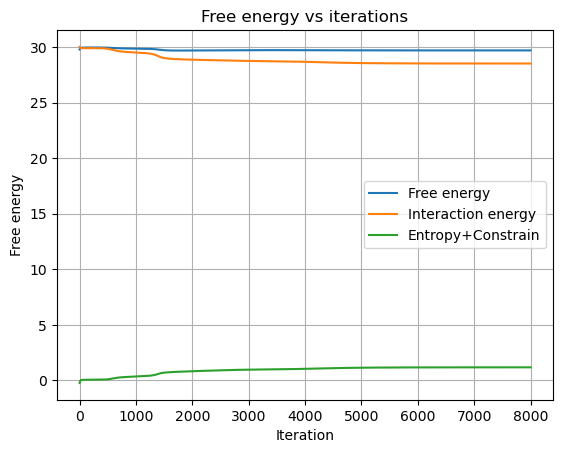

PP = 550,  PS = 325


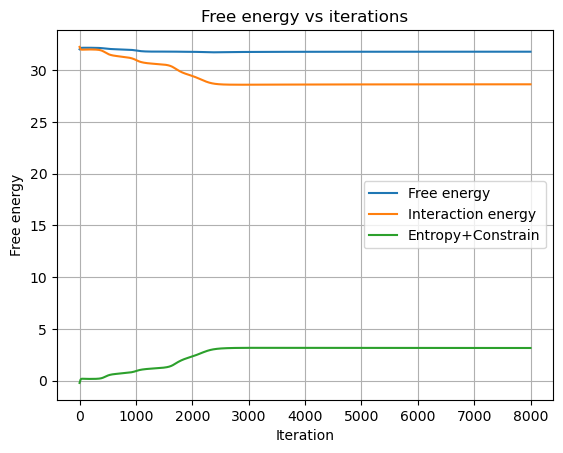

PP = 550,  PS = 350


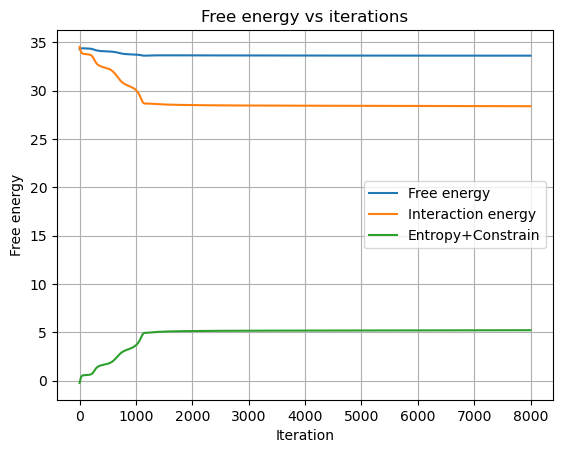

PP = 550,  PS = 400


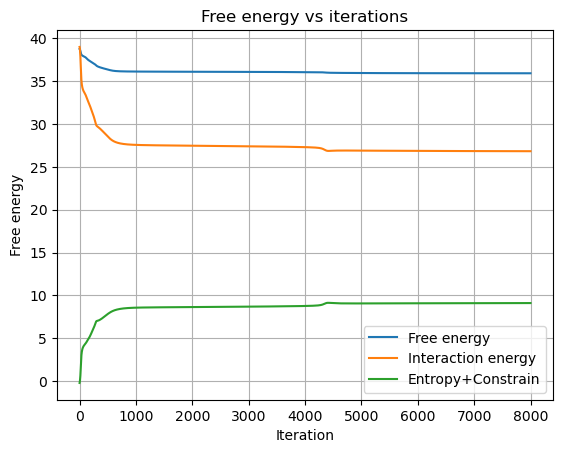

PP = 550,  PS = 450
fail


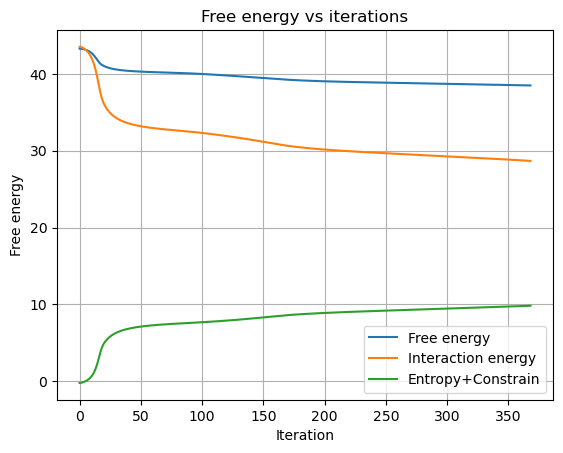

In [25]:
final_energy_grid = np.zeros((len(ChiNpp), len(ChiNps), 3))
for i in range(M):
    for j in range(K):
        print(f"PP = {int(ChiNpp[i])},  PS = {ChiNps[j]:g}")

        free_energy_hist = np.array(free_energy_grid[i,j])
        if (np.max(abs(free_energy_hist)) < 200) & (free_energy_hist.shape[0] > its):
            final_energy_grid[i,j,:] = free_energy_hist[-1,:]
        else:
            print("fail")

        plt.close('all')
        plt.plot(free_energy_hist[:, 0],label="Free energy")
        plt.plot(free_energy_hist[:, 1],label="Interaction energy")
        plt.plot(free_energy_hist[:, 2],label="Entropy+Constrain")
        #plt.yscale('log')
        plt.title("Free energy vs iterations")
        plt.ylabel("Free energy")
        plt.xlabel("Iteration")
        plt.legend()
        plt.grid()
        plt.show()
final_energy_grid = np.where(final_energy_grid == 0, np.nan, final_energy_grid)

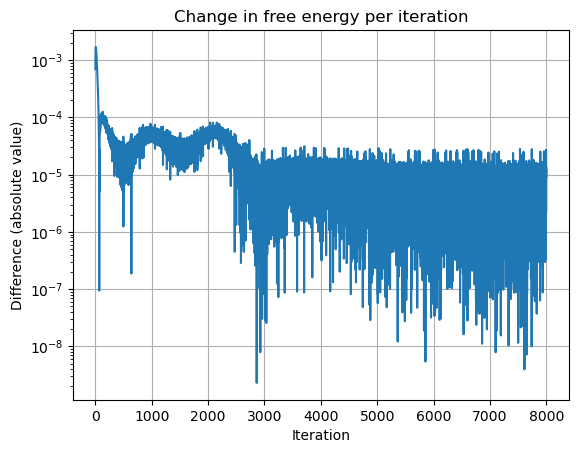

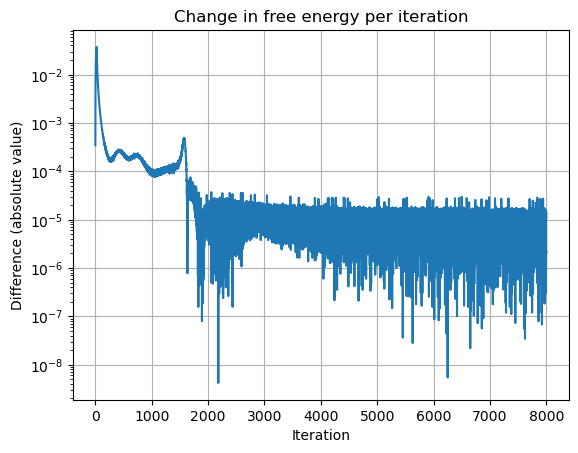

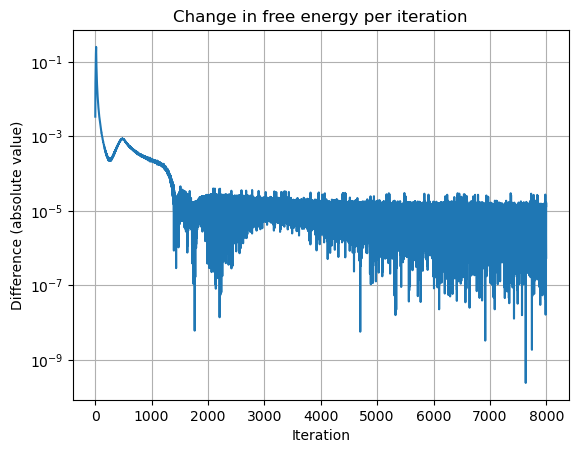

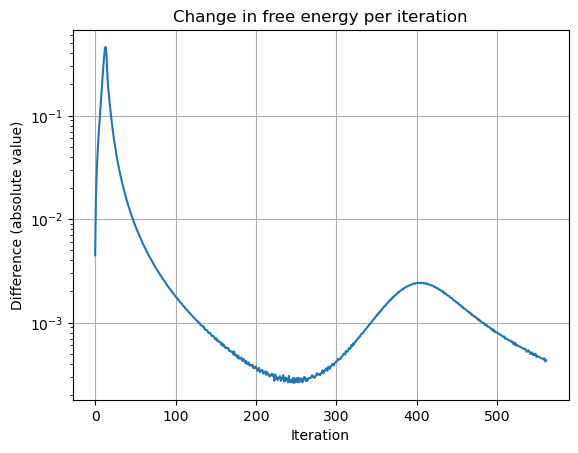

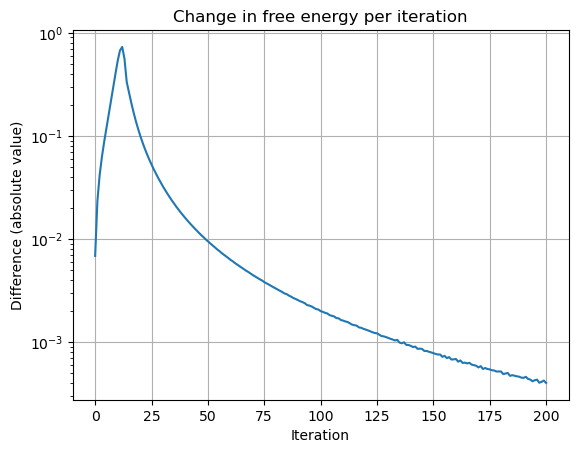

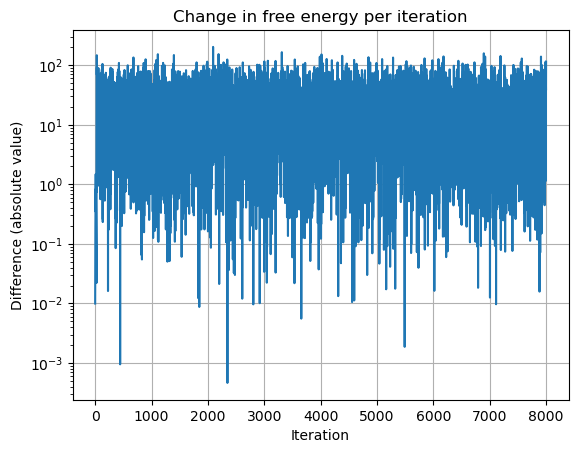

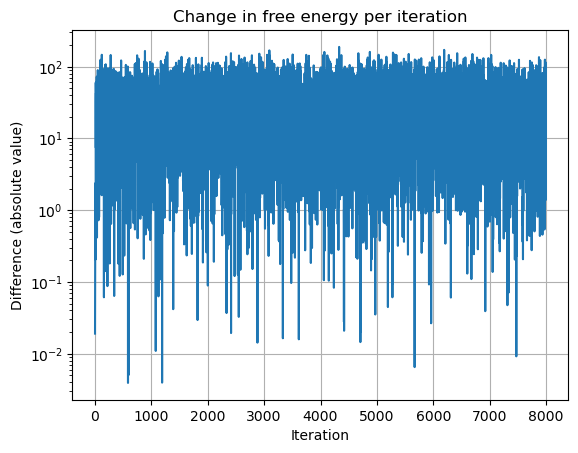

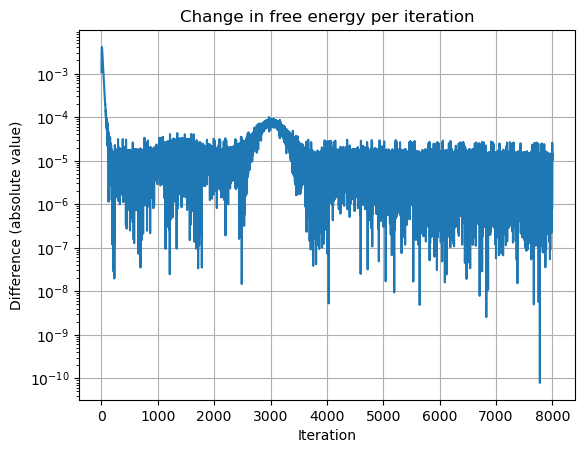

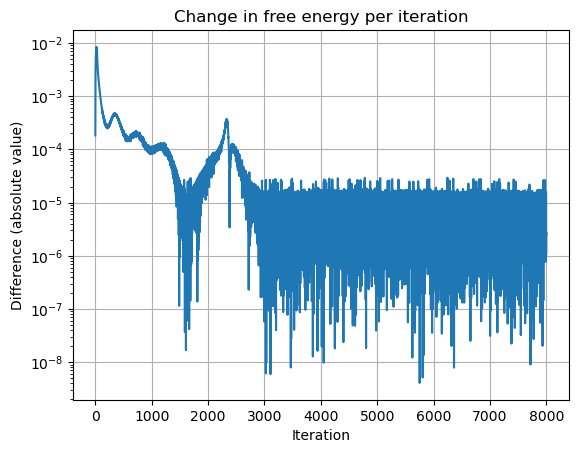

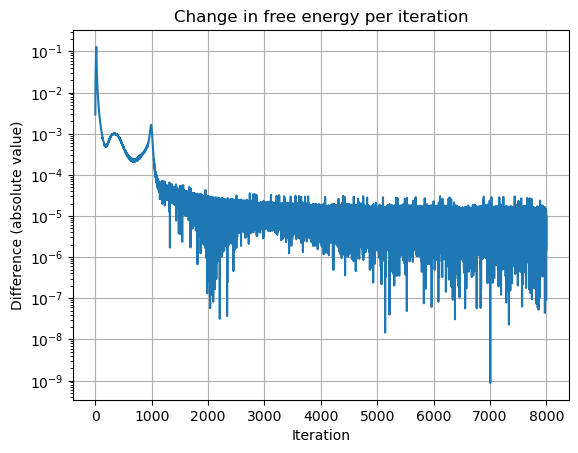

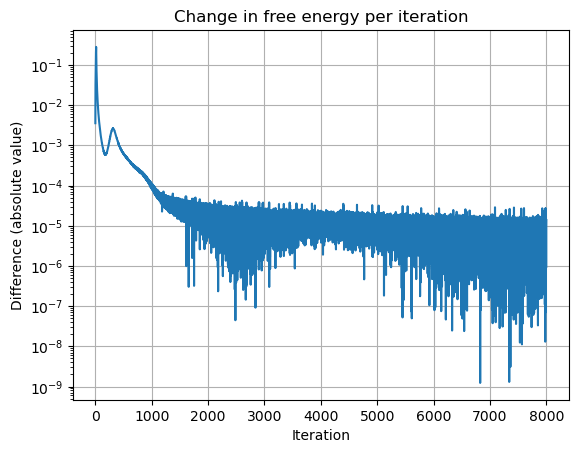

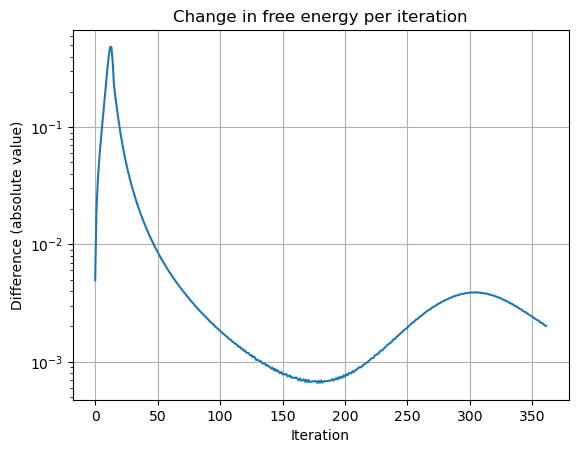

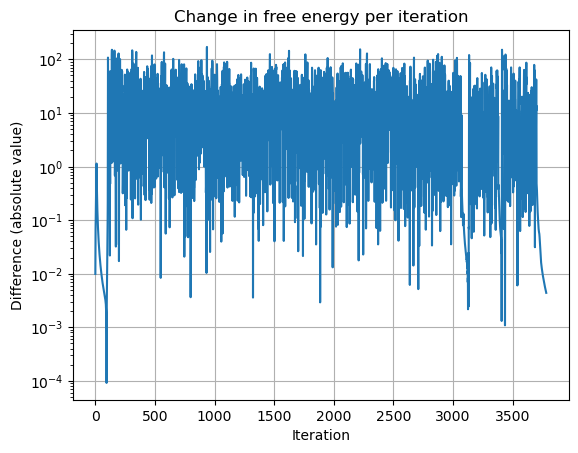

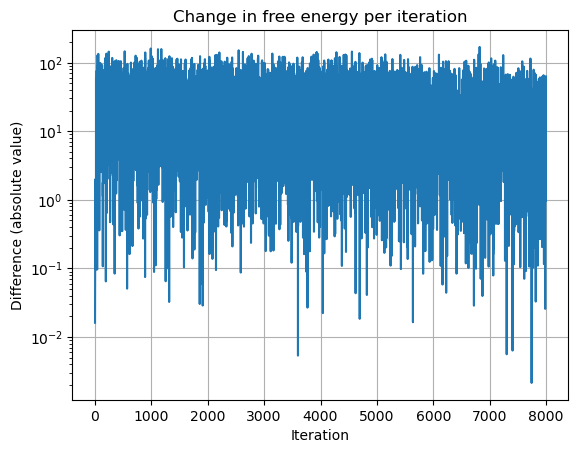

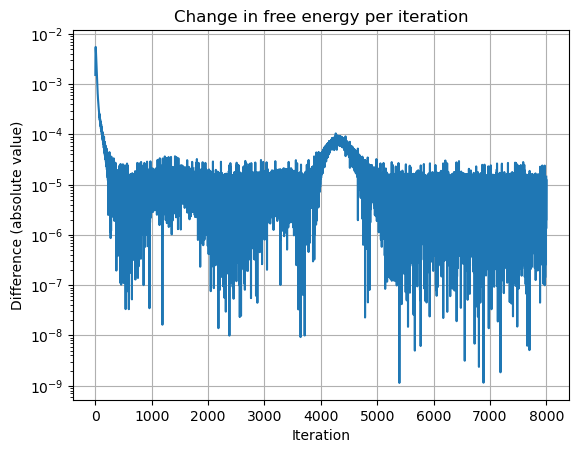

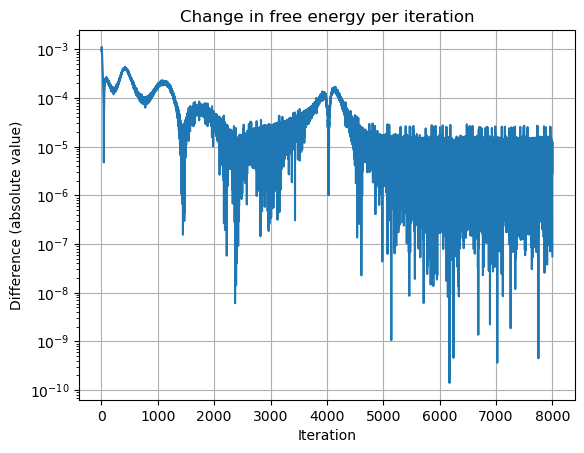

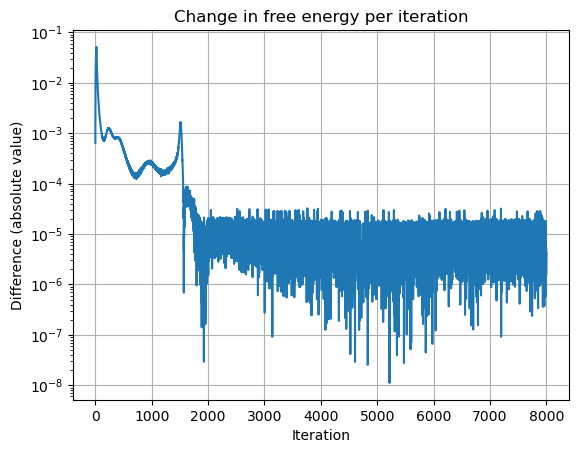

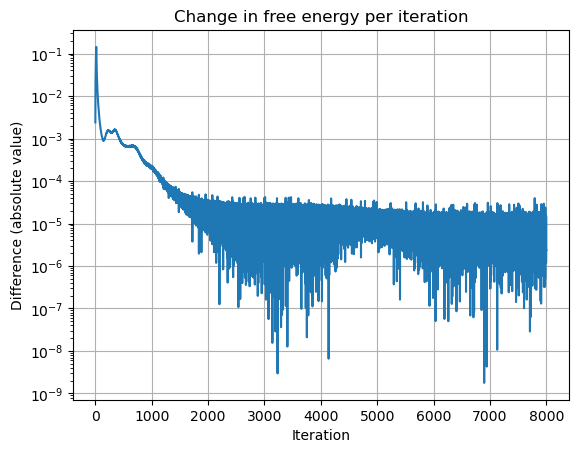

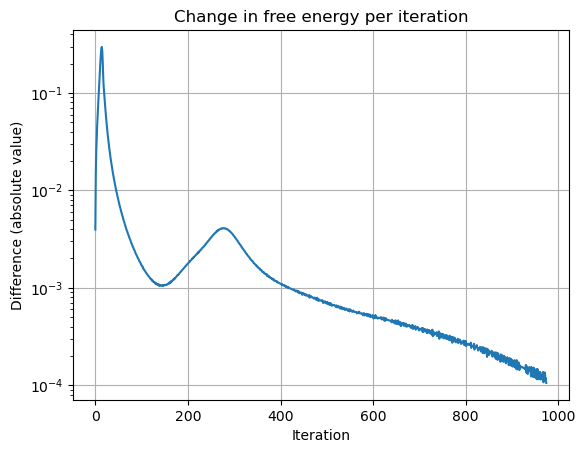

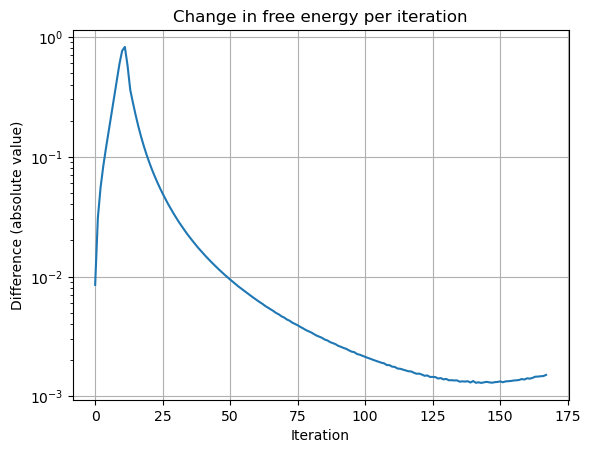

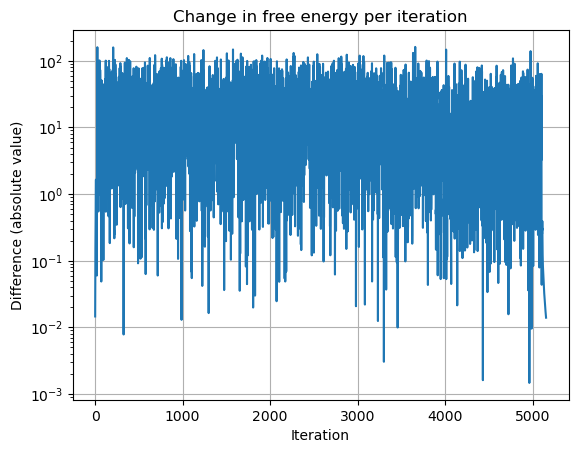

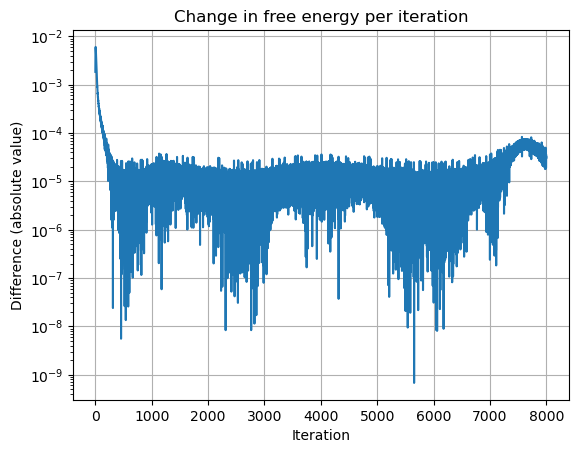

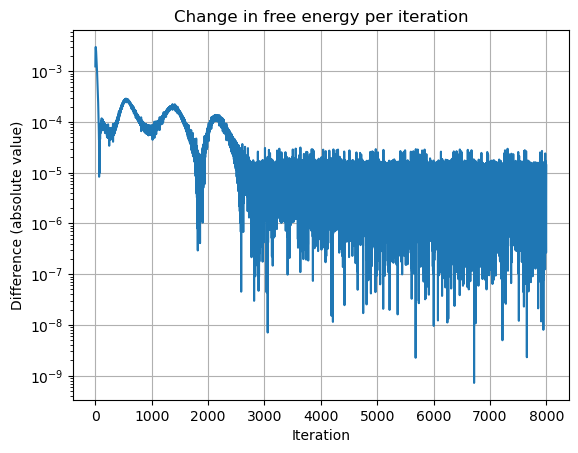

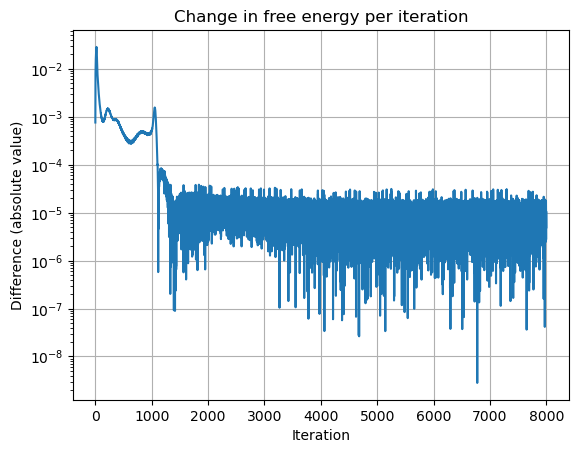

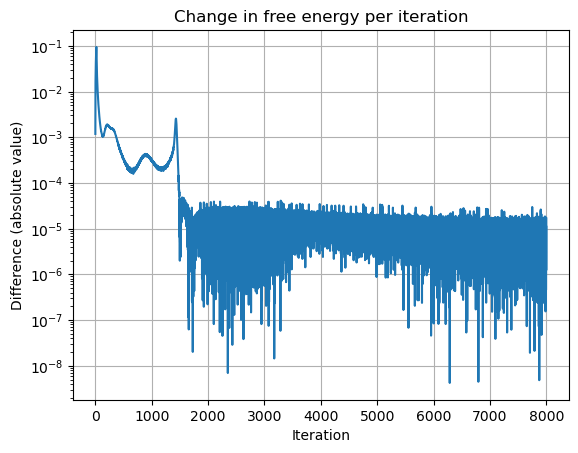

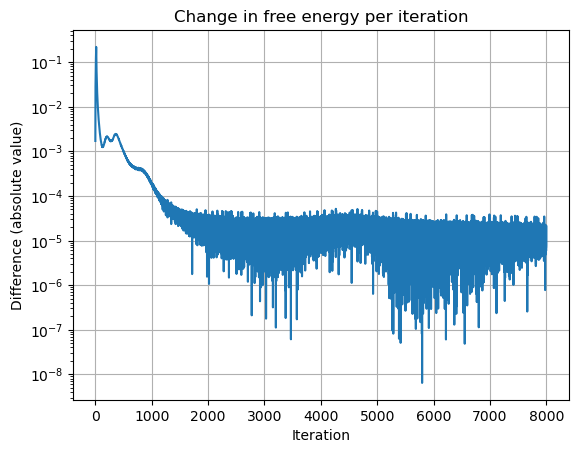

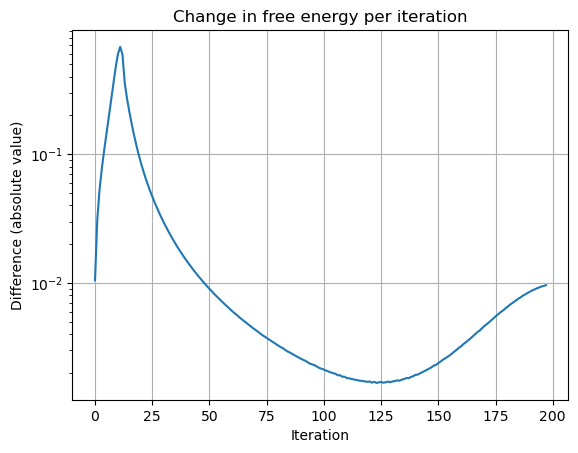

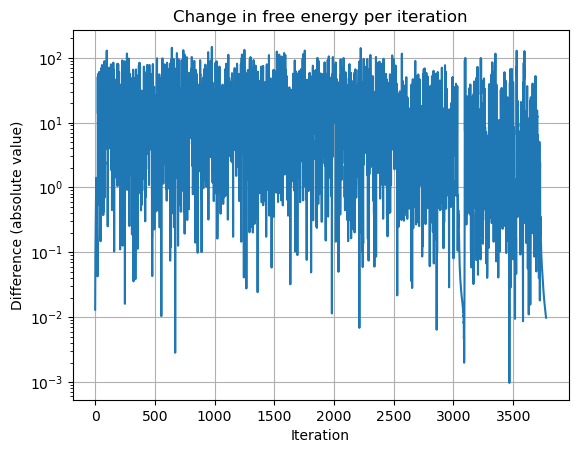

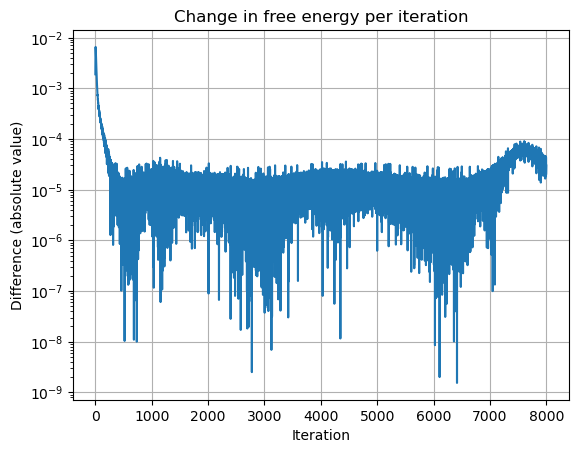

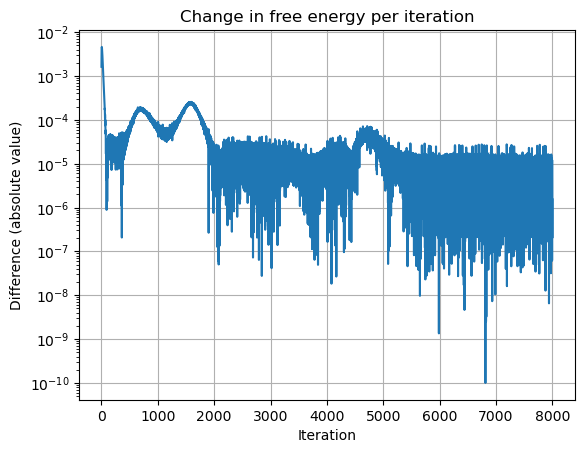

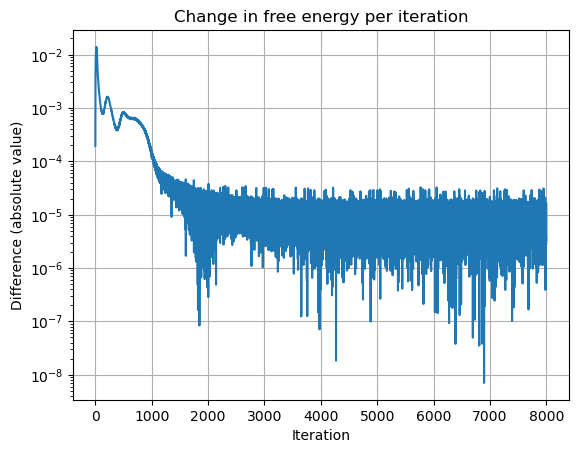

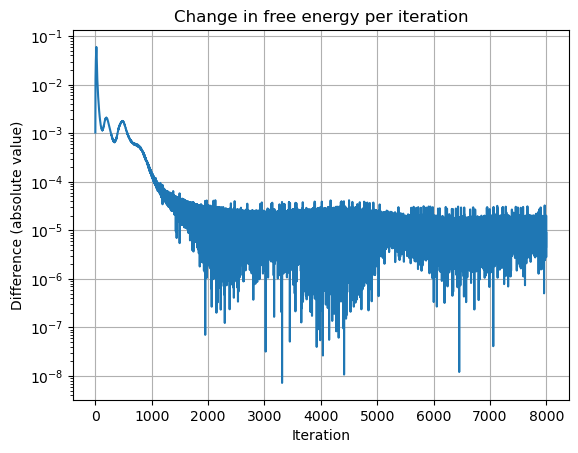

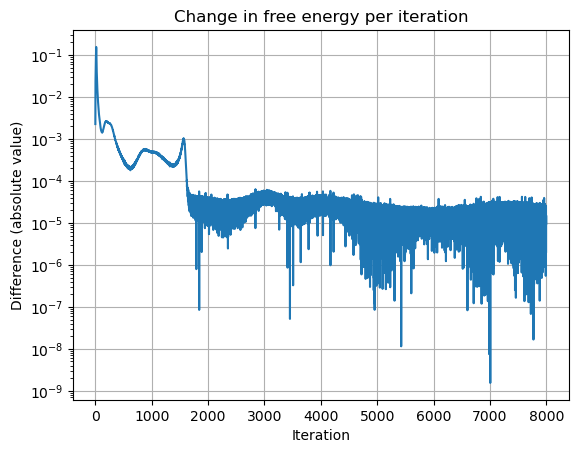

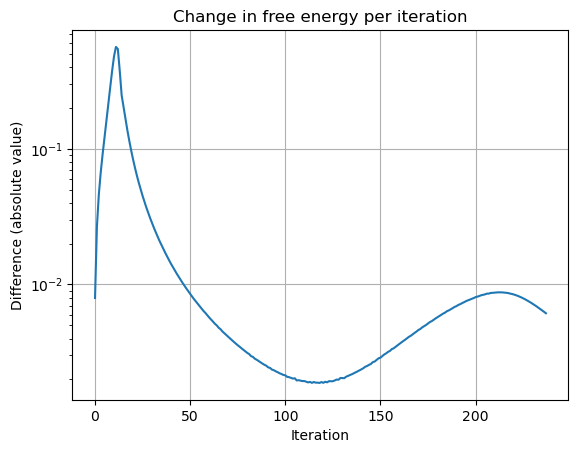

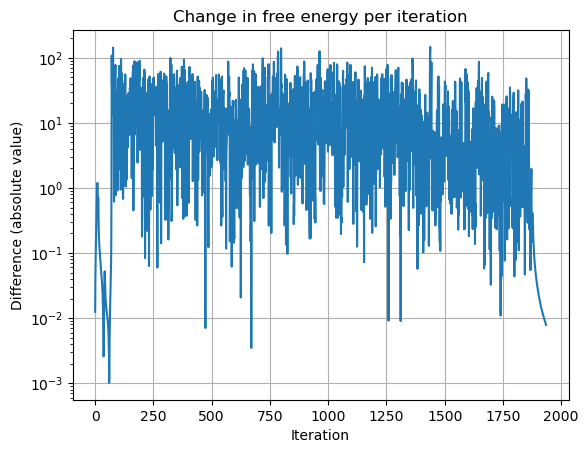

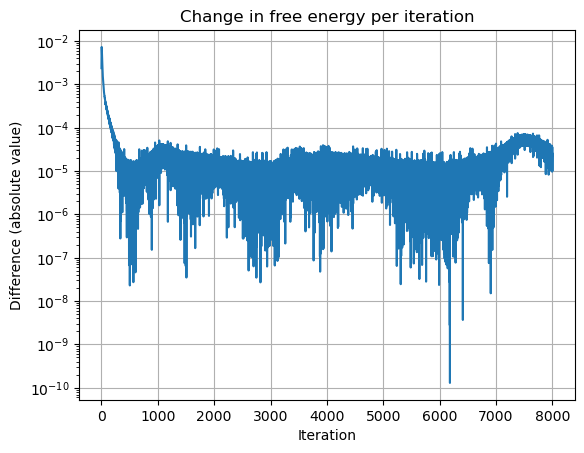

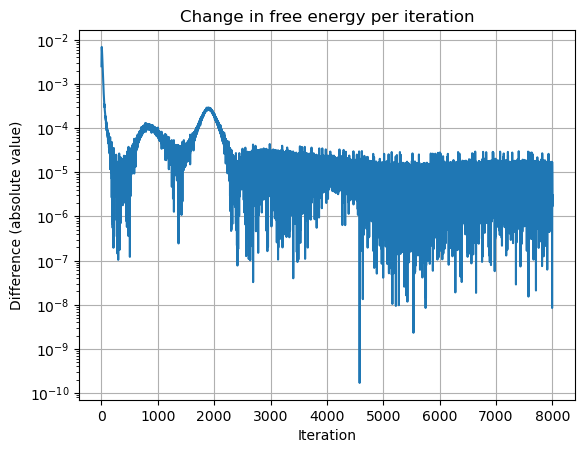

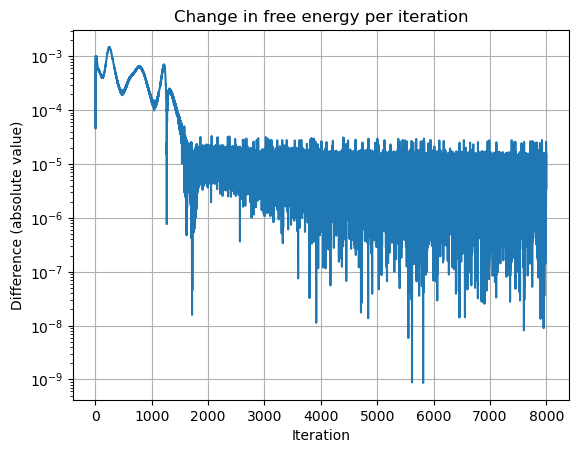

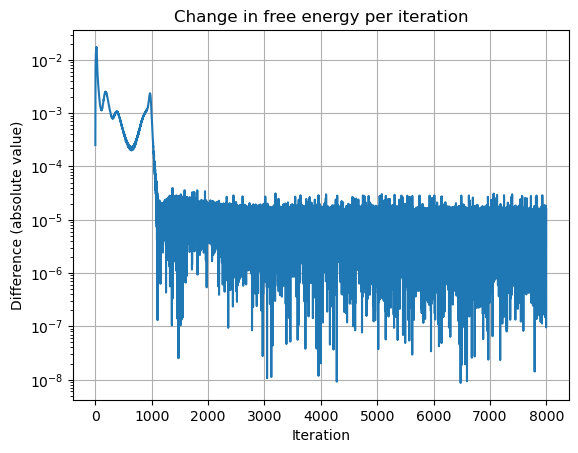

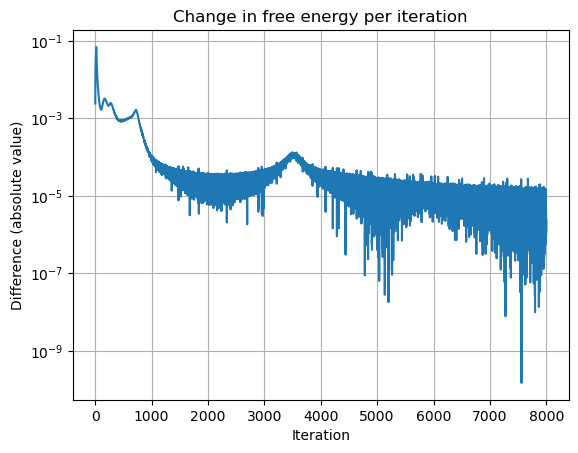

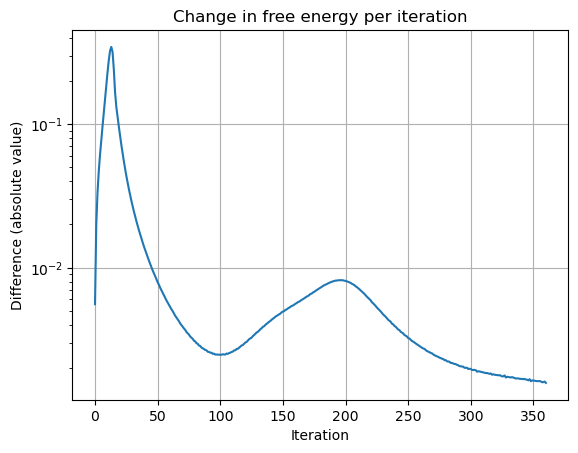

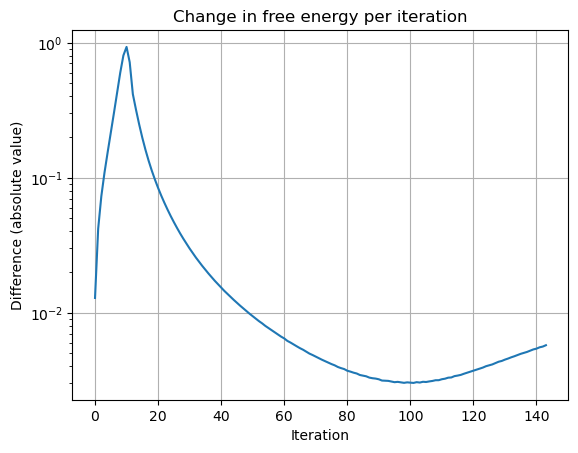

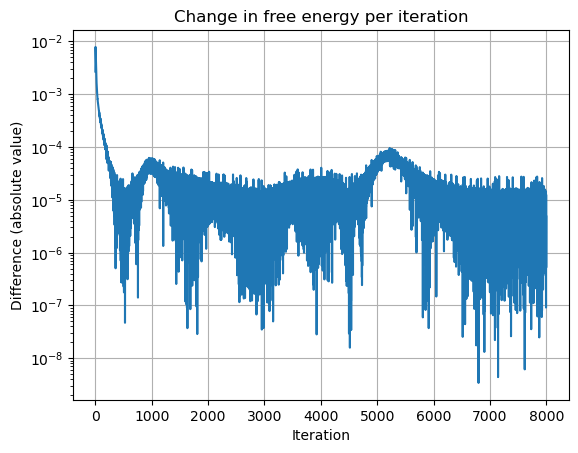

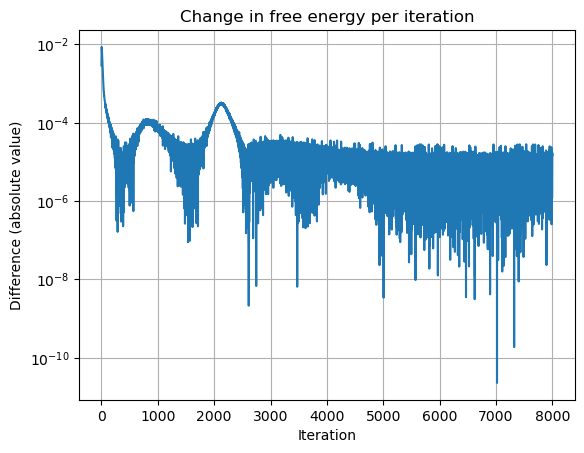

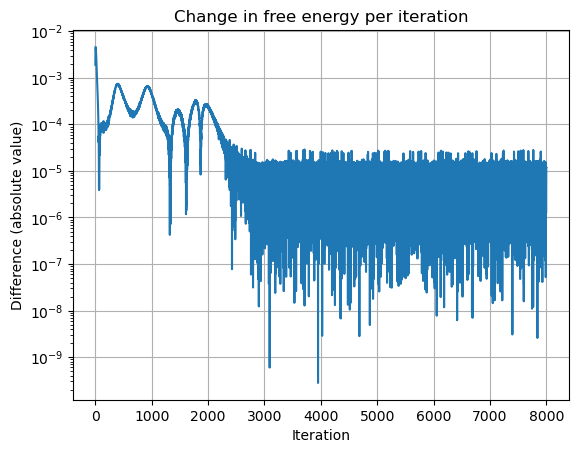

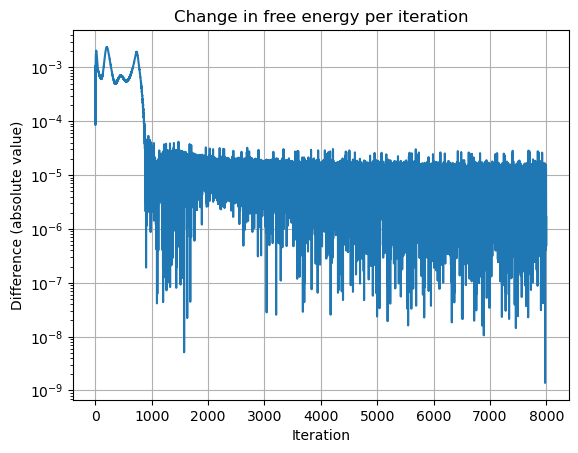

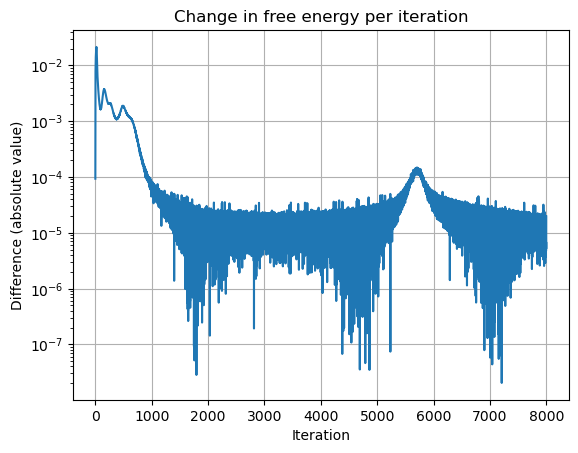

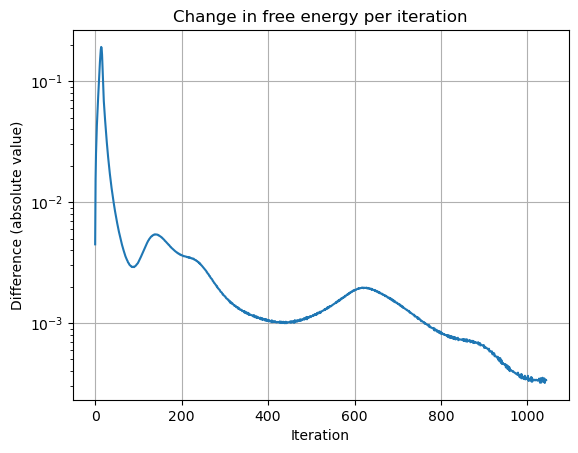

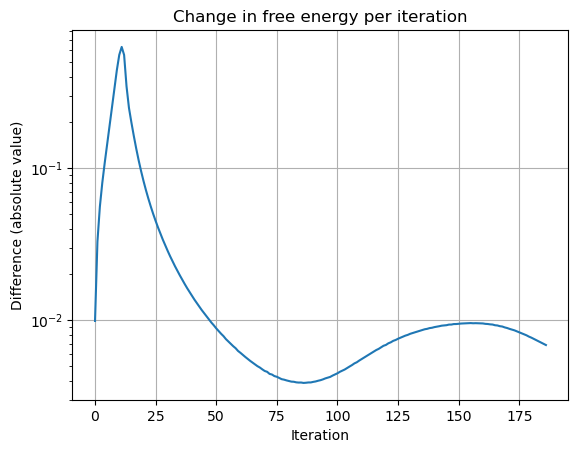

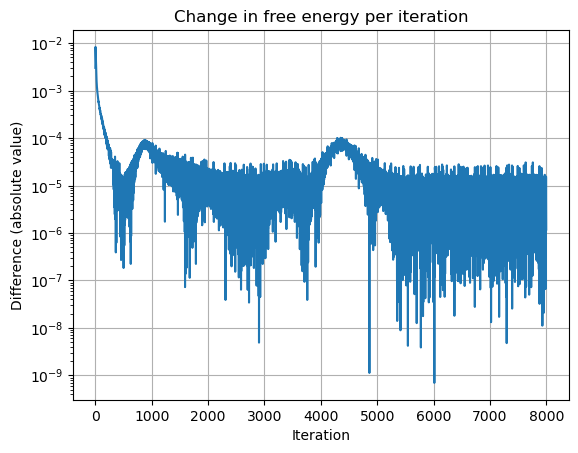

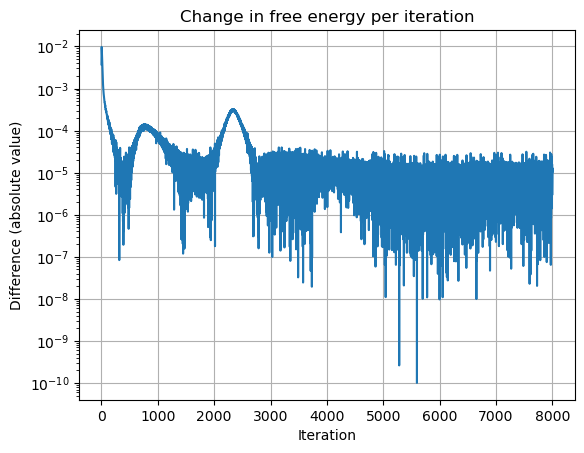

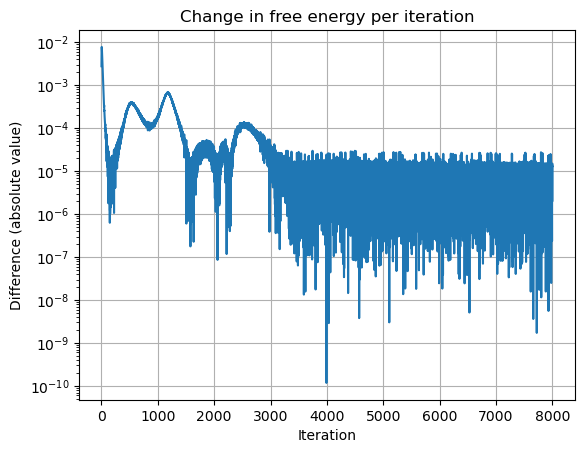

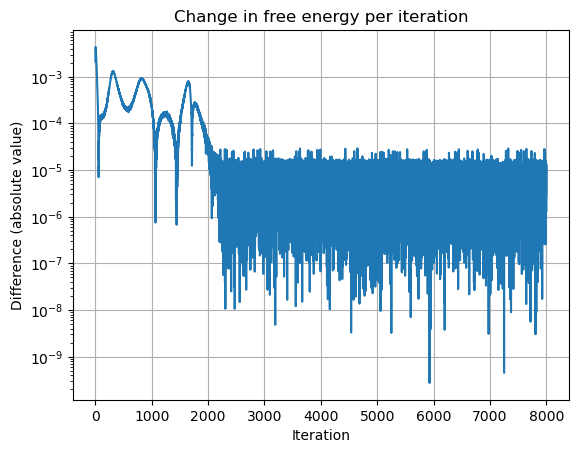

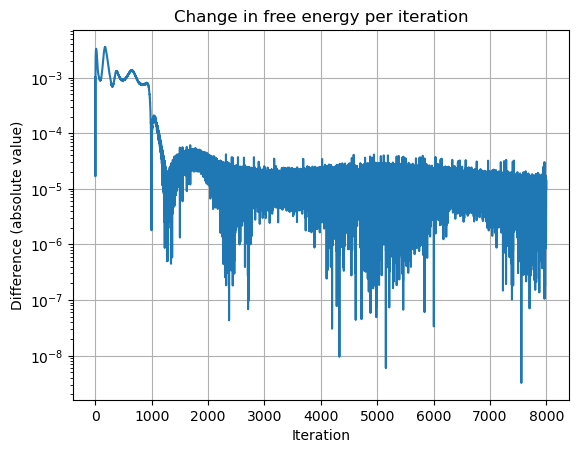

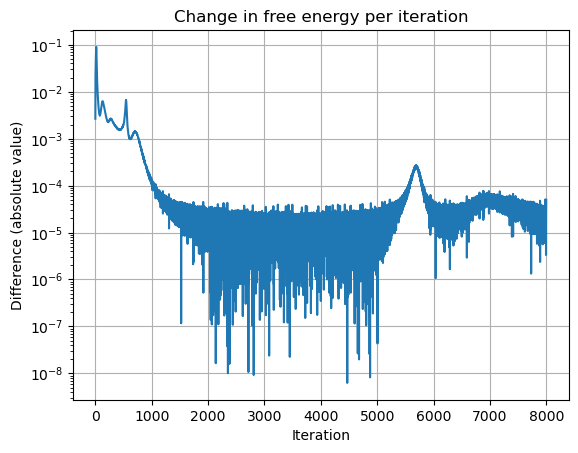

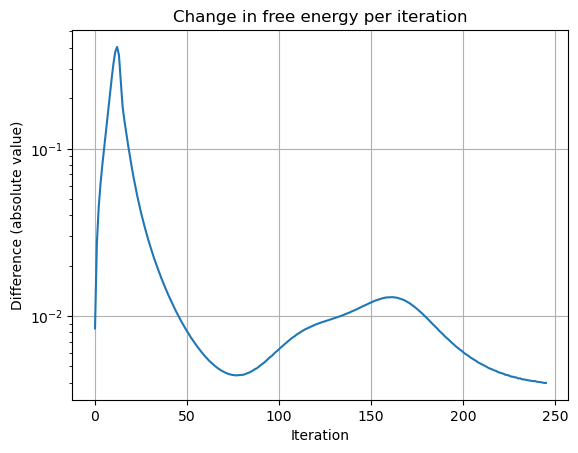

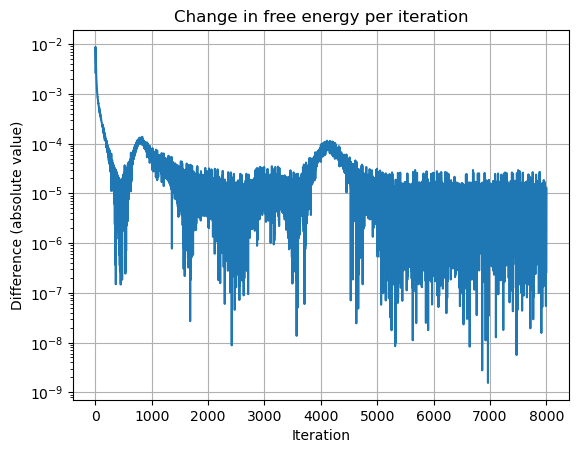

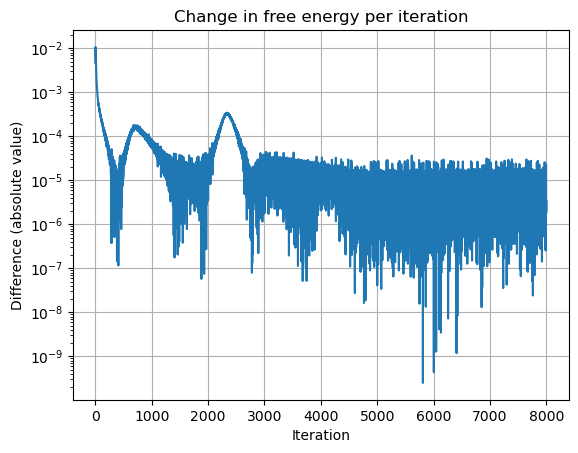

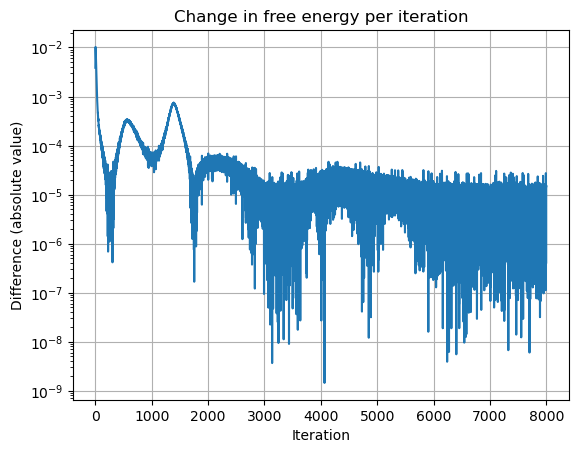

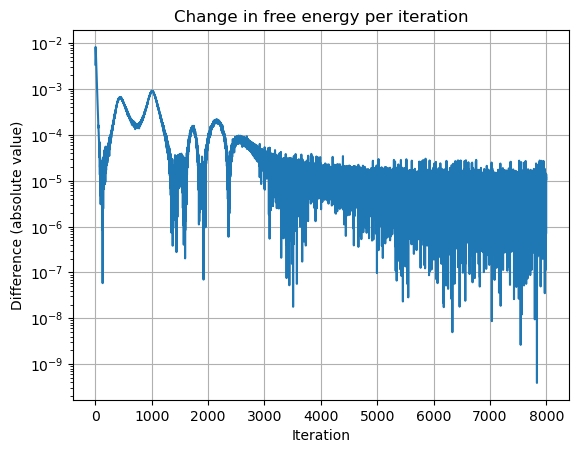

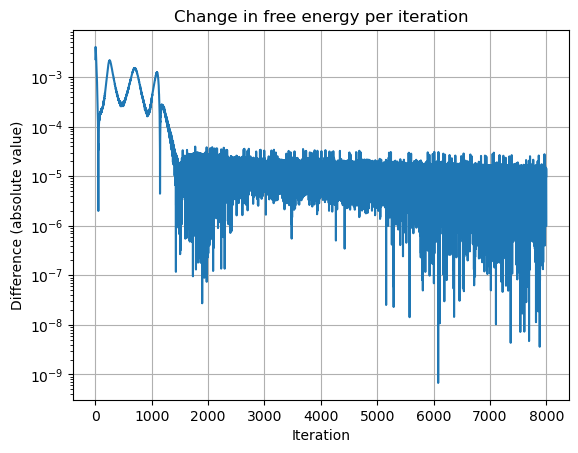

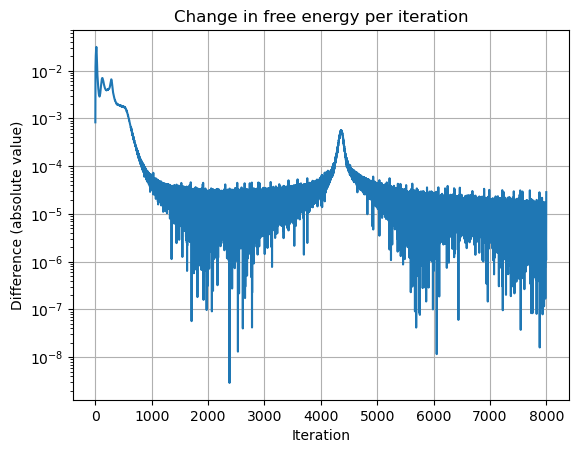

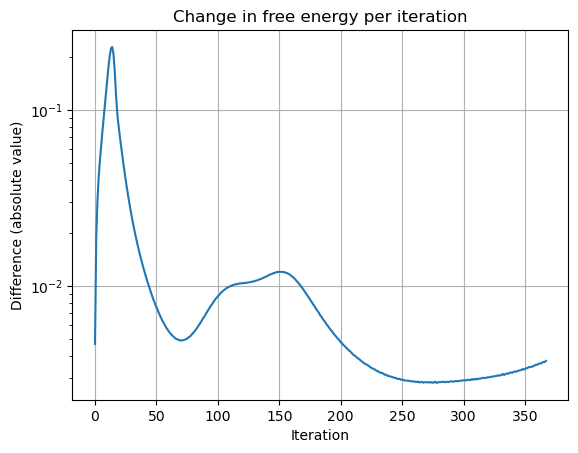

In [12]:
for i in range(M):
    for j in range(K):
        free_energy_hist = np.array(free_energy_grid[i,j])
        diff_energy = free_energy_hist[1:, 0]-free_energy_hist[:-1, 0]
        plt.plot(abs(diff_energy))
        #plt.plot(diff_energy)
        plt.yscale('log')
        plt.title("Change in free energy per iteration")
        plt.ylabel("Difference (absolute value)")
        plt.xlabel("Iteration")
        plt.grid()
        plt.show()

In [6]:
del free_energy_grid